# Task 3 — Fashion Occasion and Gender Classification

**COSC2753 Assignment 2** · Neural network approach

Given a fashion-item image, predict **who the item is intended for** (`gender`) and **what
occasion it suits** (`usage`).

## Problem framing

The specification allows gender and usage to be modelled as two separate targets or as one
combined class. This notebook uses a **multi-task convolutional neural network**: a single
shared convolutional backbone with two independent classification heads.

The justification is threefold:

1. **Shared visual features.** The cues that identify a garment as menswear (cut, colour
   palette, silhouette) largely overlap with the cues that identify it as formal or sporty.
   A shared backbone learns those features once from twice the supervisory signal.
2. **Avoids label sparsity.** A single combined class would produce 27 observed
   `gender x usage` combinations, many with fewer than 20 examples, and would make the model
   unable to predict combinations absent from training.
3. **Deployment cost.** One forward pass produces both predictions, which halves inference
   cost relative to two independent models — relevant to the application component of the
   assignment.

Single-task baselines are trained later in the notebook so this choice is supported by
evidence rather than assertion.

## Evaluation strategy

* **Grouped, stratified hold-out** (train / validation / test) for architecture and
  hyper-parameter search. Grouping is by product name because the dataset contains many
  near-identical photographs of the same product; an ungrouped split leaks them across
  partitions and inflates the score.
* **5-fold grouped cross-validation** on the winning configuration only, to quantify the
  variance of the estimate without paying 5x the cost for every experiment.
* **Macro-F1 as the primary metric.** `usage` is 76.9% `Casual`, so plain accuracy is
  misleading — a constant predictor already reaches that figure.

## Regularisation ("pruning")

For neural networks the analogues of pre- and post-pruning are:

* **Pre-pruning** — capacity is constrained *during* training: early stopping on validation
  macro-F1, dropout, weight decay, and batch normalisation.
* **Post-pruning** — the trained network is *reduced after* convergence: global magnitude
  (L1-unstructured) weight pruning followed by fine-tuning, evaluated across sparsity levels.

Both are implemented and measured below.

## 1. Setup, configuration and reproducibility

In [5]:
# ============================================
# CELL 1 - Imports, device and global configuration
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    """Seed every source of randomness we rely on."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    print("VRAM   :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
    # cuDNN autotuner: input size is fixed, so this is a free speed-up
    torch.backends.cudnn.benchmark = True

PyTorch: 2.11.0+cu128
Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM   : 6.44 GB


In [6]:
# ============================================
# CELL 2 - Paths (mirrors 01_eda.ipynb)
# ============================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATASET_ROOT / "FashionDataset"

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"
TEST_IMAGE_DIR = TEST_DIR / "images_test"

PROCESSED_DIR = DATASET_ROOT / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_METADATA = PROCESSED_DIR / "clean_train_metadata.csv"
PREDICTION_METADATA = PROCESSED_DIR / "prediction_metadata.csv"

assert CLEAN_METADATA.exists(), (
    f"Cannot find {CLEAN_METADATA}. Run 01_eda.ipynb first - it produces this file."
)

print("Processed directory:", PROCESSED_DIR)
print("Artifact directory :", ARTIFACT_DIR)

Processed directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed
Artifact directory : c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3


In [7]:
# ============================================
# CELL 3 - Experiment configuration
# ============================================

CONFIG = {
    # --- image ---
    "image_width": 60,        # native resolution from the EDA scan
    "image_height": 80,
    "channels": 3,

    # --- targets ---
    "targets": ["gender", "usage"],
    "rare_strategy": "group",     # "group" -> collapse into 'Other'; "drop" -> discard rows
    "min_class_size": 100,        # usage classes below this are rare (Home/Party/Travel/Smart Casual)

    # --- splitting ---
    "test_fraction": 0.15,
    "val_fraction": 0.15,
    "group_column": "productDisplayName",   # blocks near-duplicate leakage

    # --- training ---
    "batch_size": 128,
    "max_epochs": 60,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "early_stopping_patience": 8,    # pre-pruning
    "lr_patience": 4,
    "grad_clip": 5.0,
    "use_amp": True,                 # mixed precision on CUDA
    "task_weights": {"gender": 1.0, "usage": 1.0},
    "use_class_weights": True,

    # --- dataloader ---
    # NOTE: keep at 0 on Windows. Jupyter on Windows uses 'spawn', and worker
    # processes cannot pickle classes defined inside a notebook, which causes
    # the kernel to hang. The memmap cache below makes workers unnecessary.
    "num_workers": 0,
}

IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])   # (W, H) for PIL
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)   # (H, W, C) for arrays

print(json.dumps(CONFIG, indent=2))

{
  "image_width": 60,
  "image_height": 80,
  "channels": 3,
  "targets": [
    "gender",
    "usage"
  ],
  "rare_strategy": "group",
  "min_class_size": 100,
  "test_fraction": 0.15,
  "val_fraction": 0.15,
  "group_column": "productDisplayName",
  "batch_size": 128,
  "max_epochs": 60,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "early_stopping_patience": 8,
  "lr_patience": 4,
  "grad_clip": 5.0,
  "use_amp": true,
  "task_weights": {
    "gender": 1.0,
    "usage": 1.0
  },
  "use_class_weights": true,
  "num_workers": 0
}


## 2. Load the cleaned metadata

The notebook consumes `clean_train_metadata.csv` produced by `01_eda.ipynb`, which has already
had the CSV parsing artefacts repaired and rows without images removed. Nothing is re-derived
here, so both notebooks cannot drift apart.

In [8]:
# ============================================
# CELL 4 - Load metadata and recap the two targets
# ============================================

data = pd.read_csv(CLEAN_METADATA)
print("Rows:", len(data), "| Columns:", list(data.columns))

for target in CONFIG["targets"]:
    print("\n" + "=" * 55)
    print(target.upper(), "-", data[target].nunique(), "classes,",
          int(data[target].isna().sum()), "missing")
    print("=" * 55)
    summary = pd.DataFrame({
        "Count": data[target].value_counts(dropna=False),
        "Percent": (data[target].value_counts(dropna=False, normalize=True) * 100).round(2),
    })
    display(summary)

Rows: 38612 | Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']

GENDER - 5 classes, 0 missing


,Count,Percent
gender,,
Men,20913,54.16
Women,14160,36.67
Unisex,2080,5.39
Boys,814,2.11
Girls,645,1.67



USAGE - 8 classes, 72 missing


,Count,Percent
usage,,
Casual,29636,76.75
Sports,3940,10.20
Ethnic,2570,6.66
Formal,2300,5.96
NaN,72,0.19
Smart Casual,55,0.14
Travel,25,0.06
Party,13,0.03
Home,1,0.00


usage,Casual,Ethnic,Formal,Home,Party,Smart Casual,Sports,Travel,NaN
gender,,,,,,,,,
Boys,783,10,0,0,0,0,21,0,0
Girls,635,8,0,0,0,0,2,0,0
Men,15686,90,2193,0,0,44,2876,1,23
Unisex,1758,0,1,1,0,0,282,20,18
Women,10774,2462,106,0,13,11,759,4,31


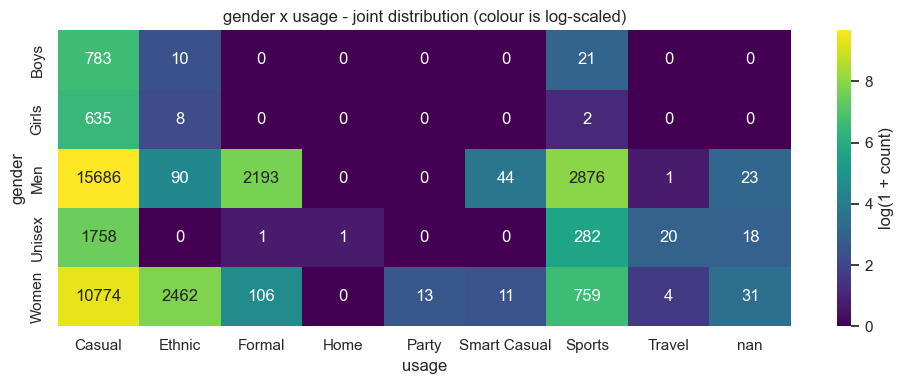

Observed gender x usage combinations: 27 of 45 possible
Combinations with fewer than 20 examples: 10


In [9]:
# ============================================
# CELL 5 - Joint distribution of the two targets
# ============================================

joint = pd.crosstab(data["gender"], data["usage"], dropna=False)
display(joint)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(np.log1p(joint), annot=joint.values, fmt="d", cmap="viridis", ax=ax,
            cbar_kws={"label": "log(1 + count)"})
ax.set_title("gender x usage - joint distribution (colour is log-scaled)")
plt.tight_layout()
plt.show()

print("Observed gender x usage combinations:",
      int((joint.values > 0).sum()), "of", joint.size, "possible")
print("Combinations with fewer than 20 examples:",
      int(((joint.values > 0) & (joint.values < 20)).sum()))

The joint table is the evidence for the modelling choice stated at the top: of the possible
`gender x usage` combinations only a minority are observed, and many of those are extremely
sparse. A single combined target would therefore spend most of its capacity on classes it can
never learn, whereas two heads share the dense marginal signal.

## 3. Target preparation

Two issues must be resolved before encoding.

**Missing `usage` labels (72 rows).** These are dropped rather than imputed. Imputing the
majority class would inject 72 confidently wrong labels into the most over-represented class,
which is precisely the class the model is already biased towards. The loss is 0.19% of the data.

**Rare `usage` classes.** `Home` (1), `Party` (13), `Travel` (25) and `Smart Casual` (55) are
far too small to learn or to stratify. They are collapsed into a single `Other` class so the
information is retained and the model can express "none of the four main occasions", rather
than being deleted. `CONFIG["rare_strategy"] = "drop"` switches to the alternative for
comparison in the report.

In [10]:
# ============================================
# CELL 6 - Resolve missing and rare target labels
# ============================================

model_df = data.copy()
n_start = len(model_df)

# 1) rows with no usage label cannot supervise the usage head
missing_usage = model_df["usage"].isna().sum()
model_df = model_df[model_df["usage"].notna()].copy()
print(f"Dropped {missing_usage} rows with a missing `usage` label "
      f"({missing_usage / n_start * 100:.2f}%)")

# gender has no missing values in this dataset, but do not assume it
missing_gender = model_df["gender"].isna().sum()
if missing_gender:
    model_df = model_df[model_df["gender"].notna()].copy()
    print(f"Dropped {missing_gender} rows with a missing `gender` label")

# 2) rare classes
for target in CONFIG["targets"]:
    counts = model_df[target].value_counts()
    rare = counts[counts < CONFIG["min_class_size"]].index.tolist()

    if not len(rare):
        model_df[target + "_label"] = model_df[target]
        print(f"`{target}`: no class below {CONFIG['min_class_size']} - unchanged "
              f"({model_df[target].nunique()} classes)")
        continue

    affected = int(counts[rare].sum())
    if CONFIG["rare_strategy"] == "group":
        model_df[target + "_label"] = model_df[target].where(
            ~model_df[target].isin(rare), "Other")
        print(f"`{target}`: collapsed {len(rare)} rare classes {rare} "
              f"({affected} rows) into 'Other'")
    else:
        model_df = model_df[~model_df[target].isin(rare)].copy()
        model_df[target + "_label"] = model_df[target]
        print(f"`{target}`: dropped {len(rare)} rare classes {rare} ({affected} rows)")

print(f"\nRows: {n_start} -> {len(model_df)}")
for target in CONFIG["targets"]:
    display(model_df[target + "_label"].value_counts().to_frame("Count"))

Dropped 72 rows with a missing `usage` label (0.19%)
`gender`: no class below 100 - unchanged (5 classes)
`usage`: collapsed 4 rare classes ['Smart Casual', 'Travel', 'Party', 'Home'] (94 rows) into 'Other'

Rows: 38612 -> 38540


,Count
gender_label,
Men,20890
Women,14129
Unisex,2062
Boys,814
Girls,645


,Count
usage_label,
Casual,29636
Sports,3940
Ethnic,2570
Formal,2300
Other,94


In [11]:
# ============================================
# CELL 7 - Encode the labels
# ============================================

from sklearn.preprocessing import LabelEncoder

encoders = {}
class_names = {}

for target in CONFIG["targets"]:
    encoder = LabelEncoder()
    model_df[target + "_y"] = encoder.fit_transform(model_df[target + "_label"].astype(str))
    encoders[target] = encoder
    class_names[target] = list(encoder.classes_)
    print(f"{target:8s} -> {len(encoder.classes_)} classes: {list(encoder.classes_)}")

NUM_CLASSES = {t: len(encoders[t].classes_) for t in CONFIG["targets"]}

# Persist immediately - predictions cannot be decoded without these
with open(ARTIFACT_DIR / "label_classes.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("\nSaved", ARTIFACT_DIR / "label_classes.json")

gender   -> 5 classes: ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
usage    -> 5 classes: ['Casual', 'Ethnic', 'Formal', 'Other', 'Sports']

Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\label_classes.json


## 4. Baselines

Before any model is trained, the numbers it must beat are established. Two references are used:

* **Majority-class** — always predict the most frequent class. This is the honest floor.
* **Stratified random** — sample predictions from the training distribution. This shows what
  macro-F1 looks like for a model that has learned nothing but the priors.

Reporting accuracy alone would be actively misleading for `usage`, where the majority class is
roughly 77% of the data.

In [12]:
# ============================================
# CELL 8 - Majority-class and random baselines
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

baseline_rows = []
X_dummy = np.zeros((len(model_df), 1))

for target in CONFIG["targets"]:
    y = model_df[target + "_y"].values
    for strategy in ["most_frequent", "stratified"]:
        dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
        dummy.fit(X_dummy, y)
        pred = dummy.predict(X_dummy)
        baseline_rows.append({
            "Target": target,
            "Baseline": strategy,
            "Accuracy": round(accuracy_score(y, pred) * 100, 2),
            "MacroF1": round(f1_score(y, pred, average="macro") * 100, 2),
            "BalancedAcc": round(balanced_accuracy_score(y, pred) * 100, 2),
        })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

BASELINE = {
    t: baseline_df[(baseline_df["Target"] == t) &
                   (baseline_df["Baseline"] == "most_frequent")].iloc[0].to_dict()
    for t in CONFIG["targets"]
}
print("Targets to beat (majority class):")
for t, row in BASELINE.items():
    print(f"  {t:8s} accuracy {row['Accuracy']:.2f}%  macro-F1 {row['MacroF1']:.2f}%")

,Target,Baseline,Accuracy,MacroF1,BalancedAcc
0,gender,most_frequent,54.20,14.06,20.00
1,gender,stratified,43.10,20.23,20.23
2,usage,most_frequent,76.90,17.39,20.00
3,usage,stratified,61.31,20.12,20.12


Targets to beat (majority class):
  gender   accuracy 54.20%  macro-F1 14.06%
  usage    accuracy 76.90%  macro-F1 17.39%


## 5. Grouped, stratified train / validation / test split

Three constraints must hold simultaneously:

1. **No group leakage.** Rows sharing a `productDisplayName` are near-identical photographs and
   must stay together. The EDA found over 15,000 such rows.
2. **Stratification on both targets.** Stratifying on `gender` alone can starve a `usage` class,
   and vice versa. The split is therefore stratified on the *combined* `gender x usage` label,
   which preserves both marginals.
3. **A genuine held-out test set.** The provided `images_test` has no labels, so the reported
   test performance must come from data this notebook never trains or tunes on.

In [13]:
# ============================================
# CELL 9 - Three-way grouped stratified split
# ============================================

from sklearn.model_selection import StratifiedGroupKFold

# stratification key combines both targets so neither marginal is distorted
model_df["_strat"] = (
    model_df["gender_label"].astype(str) + "|" + model_df["usage_label"].astype(str)
)

# combinations too small to stratify are pooled into a catch-all key
strat_counts = model_df["_strat"].value_counts()
tiny = strat_counts[strat_counts < 10].index
model_df.loc[model_df["_strat"].isin(tiny), "_strat"] = "RARE_COMBO"
print("Stratification keys:", model_df["_strat"].nunique(),
      f"(pooled {len(tiny)} combinations with <10 rows)")

groups = model_df[CONFIG["group_column"]].fillna(model_df["id"].astype(str))


def grouped_split(df, strat, grp, fraction, seed):
    """Hold out approximately `fraction` of rows, grouped and stratified."""
    n_splits = max(2, int(round(1 / fraction)))
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    keep_idx, hold_idx = next(splitter.split(df, strat, grp))
    return df.iloc[keep_idx], df.iloc[hold_idx]


# test split first, so it is untouched by everything that follows
trainval_df, test_df = grouped_split(
    model_df, model_df["_strat"], groups, CONFIG["test_fraction"], RANDOM_STATE
)

# then carve validation out of the remainder
tv_groups = trainval_df[CONFIG["group_column"]].fillna(trainval_df["id"].astype(str))
val_fraction_adj = CONFIG["val_fraction"] / (1 - CONFIG["test_fraction"])
train_df, val_df = grouped_split(
    trainval_df, trainval_df["_strat"], tv_groups, val_fraction_adj, RANDOM_STATE
)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:6s} {len(part):>6d} rows  ({len(part) / len(model_df) * 100:.1f}%)")

Stratification keys: 18 (pooled 3 combinations with <10 rows)
train   27528 rows  (71.4%)
val      5506 rows  (14.3%)
test     5506 rows  (14.3%)


In [14]:
# ============================================
# CELL 10 - Verify the split (leakage and stratification)
# ============================================

g_train = set(train_df[CONFIG["group_column"]].fillna(train_df["id"].astype(str)))
g_val = set(val_df[CONFIG["group_column"]].fillna(val_df["id"].astype(str)))
g_test = set(test_df[CONFIG["group_column"]].fillna(test_df["id"].astype(str)))

print("Group overlap train/val :", len(g_train & g_val))
print("Group overlap train/test:", len(g_train & g_test))
print("Group overlap val/test  :", len(g_val & g_test))
assert not (g_train & g_val), "Leakage between train and validation"
assert not (g_train & g_test), "Leakage between train and test"
assert not (g_val & g_test), "Leakage between validation and test"

# id-level check as a belt-and-braces guard
assert not (set(train_df["id"]) & set(val_df["id"]))
assert not (set(train_df["id"]) & set(test_df["id"]))
assert not (set(val_df["id"]) & set(test_df["id"]))

for target in CONFIG["targets"]:
    comparison = pd.DataFrame({
        "train %": train_df[target + "_label"].value_counts(normalize=True) * 100,
        "val %": val_df[target + "_label"].value_counts(normalize=True) * 100,
        "test %": test_df[target + "_label"].value_counts(normalize=True) * 100,
    }).round(2)
    print(f"\nClass distribution across splits - {target}")
    display(comparison)

    # every class must appear in every split, otherwise metrics are undefined
    for split_name, part in [("val", val_df), ("test", test_df)]:
        missing = set(train_df[target + "_label"]) - set(part[target + "_label"])
        if missing:
            print(f"  WARNING: classes absent from {split_name}: {missing}")

Group overlap train/val : 0
Group overlap train/test: 0
Group overlap val/test  : 0

Class distribution across splits - gender


,train %,val %,test %
gender_label,,,
Men,54.21,54.20,54.18
Women,36.66,36.65,36.67
Unisex,5.35,5.36,5.36
Boys,2.11,2.11,2.11
Girls,1.67,1.69,1.69



Class distribution across splits - usage


,train %,val %,test %
usage_label,,,
Casual,76.89,76.92,76.90
Sports,10.22,10.24,10.24
Ethnic,6.67,6.65,6.67
Formal,5.97,5.96,5.96
Other,0.25,0.24,0.24


## 6. Image pipeline

Decoding ~38,000 JPEGs on every epoch is the dominant cost on a GPU — the accelerator would sit
idle waiting for the CPU. The images are therefore decoded **once** into a `uint8` memory-mapped
array (~556 MB at 60x80x3) and indexed directly thereafter. This also removes the need for
DataLoader worker processes, which are unreliable inside Jupyter on Windows.

Every image is converted to RGB (the EDA found 343 greyscale files) and explicitly resized (17
files are not at the modal resolution).

In [15]:
# ============================================
# CELL 11 - Build (or load) the uint8 image cache
# ============================================

CACHE_X = PROCESSED_DIR / f"image_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = PROCESSED_DIR / f"image_cache_{CONFIG['image_width']}x{CONFIG['image_height']}_ids.npy"


def load_image_array(path, size=IMAGE_SIZE_PIL):
    """Single source of truth for reading one image (train and test alike)."""
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


all_ids = model_df["id"].to_numpy()

if CACHE_X.exists() and CACHE_IDS.exists():
    cached_ids = np.load(CACHE_IDS)
    if len(cached_ids) == len(all_ids) and (cached_ids == all_ids).all():
        IMAGES = np.load(CACHE_X, mmap_mode="r")
        print("Loaded image cache:", IMAGES.shape, IMAGES.dtype)
    else:
        print("Cache does not match the current row selection - rebuilding")
        CACHE_X.unlink(missing_ok=True)

if not CACHE_X.exists():
    print(f"Building cache for {len(model_df)} images ...")
    IMAGES = np.lib.format.open_memmap(
        CACHE_X, mode="w+", dtype=np.uint8, shape=(len(model_df),) + IMAGE_SHAPE
    )
    start = time.time()
    for position, path in enumerate(model_df["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 5000 == 0:
            print(f"  {position + 1}/{len(model_df)} ({time.time() - start:.0f}s)")
    IMAGES.flush()
    np.save(CACHE_IDS, all_ids)
    print(f"Cache built in {time.time() - start:.0f}s ->", CACHE_X)

# position in IMAGES for each dataframe row - the two must never drift apart
id_to_position = {image_id: position for position, image_id in enumerate(all_ids)}
for part in (train_df, val_df, test_df):
    part["cache_position"] = part["id"].map(id_to_position).astype(int)

# alignment check on a random row
probe = train_df.sample(1, random_state=RANDOM_STATE).iloc[0]
assert np.array_equal(
    np.asarray(IMAGES[probe["cache_position"]]), load_image_array(probe["image_path"])
), "Image cache is out of sync with the metadata"
print("Cache alignment verified.")

Building cache for 38540 images ...
  5000/38540 (3s)
  10000/38540 (8s)
  15000/38540 (11s)
  20000/38540 (14s)
  25000/38540 (18s)
  30000/38540 (24s)
  35000/38540 (29s)
Cache built in 33s -> c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed\image_cache_60x80.npy
Cache alignment verified.


In [16]:
# ============================================
# CELL 12 - Channel statistics from the TRAINING split only
# ============================================

# Computing normalisation statistics over the whole dataset would leak information
# from validation and test into training.
sample_positions = train_df["cache_position"].sample(
    min(4000, len(train_df)), random_state=RANDOM_STATE
).to_numpy()
sample_pixels = np.asarray(IMAGES[np.sort(sample_positions)], dtype=np.float32) / 255.0

CHANNEL_MEAN = sample_pixels.mean(axis=(0, 1, 2))
CHANNEL_STD = sample_pixels.std(axis=(0, 1, 2))

print("Channel mean:", CHANNEL_MEAN.round(4))
print("Channel std :", CHANNEL_STD.round(4))

del sample_pixels

Channel mean: [0.8557 0.8366 0.8272]
Channel std : [0.2531 0.2595 0.2598]


In [17]:
# ============================================
# CELL 13 - Dataset and augmentation
# ============================================

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.06, 0.06), scale=(0.90, 1.10)),
    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(CHANNEL_MEAN.tolist(), CHANNEL_STD.tolist()),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.10)),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(CHANNEL_MEAN.tolist(), CHANNEL_STD.tolist()),
])


class FashionMultiTaskDataset(Dataset):
    """Serves (image, gender_label, usage_label) triples from the memmap cache."""

    def __init__(self, frame, images, transform):
        self.positions = frame["cache_position"].to_numpy()
        self.gender = frame["gender_y"].to_numpy()
        self.usage = frame["usage_y"].to_numpy()
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(self.images[self.positions[index]])
        image = self.transform(array)
        return image, int(self.gender[index]), int(self.usage[index])


def make_loader(frame, train=False, batch_size=None):
    dataset = FashionMultiTaskDataset(
        frame, IMAGES, train_transform if train else eval_transform
    )
    return DataLoader(
        dataset,
        batch_size=batch_size or CONFIG["batch_size"],
        shuffle=train,
        num_workers=CONFIG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


train_loader = make_loader(train_df, train=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images_batch, gender_batch, usage_batch = next(iter(train_loader))
print("Batch:", images_batch.shape, images_batch.dtype)
print("Gender labels:", gender_batch.shape, "| Usage labels:", usage_batch.shape)
print("Classes:", NUM_CLASSES)

Batch: torch.Size([128, 3, 80, 60]) torch.float32
Gender labels: torch.Size([128]) | Usage labels: torch.Size([128])
Classes: {'gender': 5, 'usage': 5}


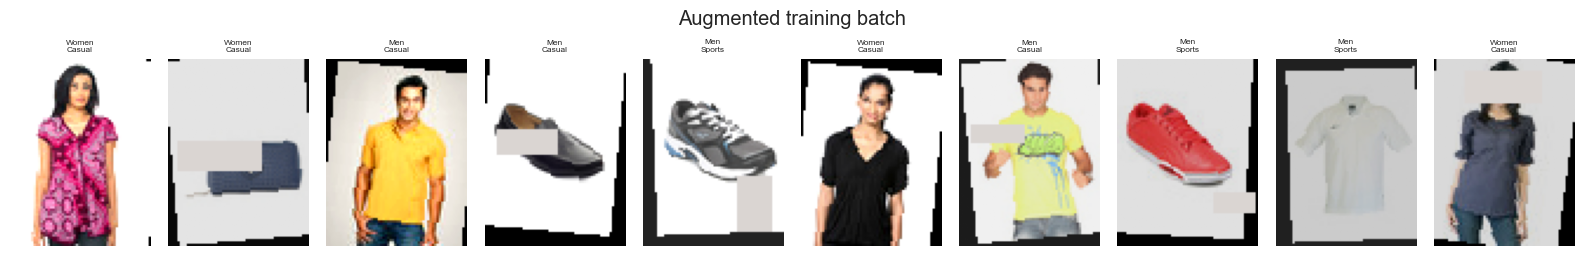

In [18]:
# ============================================
# CELL 14 - Inspect an augmented batch
# ============================================

denormalised = (
    images_batch[:10].permute(0, 2, 3, 1).numpy() * CHANNEL_STD + CHANNEL_MEAN
)

fig, axes = plt.subplots(1, 10, figsize=(16, 2.6))
for ax, image, g, u in zip(axes, denormalised, gender_batch[:10], usage_batch[:10]):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(f"{class_names['gender'][g]}\n{class_names['usage'][u]}", fontsize=6)
    ax.axis("off")
plt.suptitle("Augmented training batch")
plt.tight_layout()
plt.show()

## 7. Class imbalance

`gender` ranges from 20,913 (`Men`) to 645 (`Girls`); `usage` is 77% `Casual`. Without
intervention the network minimises loss by predicting the majority class, which is exactly the
behaviour the baseline already achieves.

Inverse-frequency class weights are applied to each head's loss. Weights are computed on the
**training split only**, and are capped to avoid a single tiny class dominating the gradient.

In [19]:
# ============================================
# CELL 15 - Class weights per head
# ============================================

from sklearn.utils.class_weight import compute_class_weight

WEIGHT_CAP = 10.0
class_weights = {}

for target in CONFIG["targets"]:
    y_train = train_df[target + "_y"].to_numpy()
    present = np.unique(y_train)

    weights = np.ones(NUM_CLASSES[target], dtype=np.float32)
    computed = compute_class_weight("balanced", classes=present, y=y_train)
    weights[present] = computed
    weights = np.clip(weights, 0.0, WEIGHT_CAP)

    class_weights[target] = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

    display(pd.DataFrame({
        "Class": class_names[target],
        "TrainCount": [int((y_train == i).sum()) for i in range(NUM_CLASSES[target])],
        "Weight": weights.round(3),
    }))

,Class,TrainCount,Weight
0,Boys,582,9.460
1,Girls,459,10.000
2,Men,14923,0.369
3,Unisex,1472,3.740
4,Women,10092,0.546


,Class,TrainCount,Weight
0,Casual,21167,0.260
1,Ethnic,1837,2.997
2,Formal,1644,3.349
3,Other,68,10.000
4,Sports,2812,1.958


## 8. Model architecture

A convolutional network trained **from scratch** — the specification forbids pretrained weights
from outside the assignment data.

* **Shared backbone.** Four convolutional blocks (Conv-BN-ReLU x2 then max-pool), widening
  32 -> 64 -> 128 -> 256. Batch normalisation stabilises training at higher learning rates and
  contributes regularisation; the doubling width compensates for the shrinking spatial map.
* **Global average pooling** instead of flattening. This removes roughly 90% of the parameters
  a dense layer would add, which is the single most effective structural defence against
  overfitting on 27k training images.
* **Two heads.** Each head is `Dropout -> Linear -> ReLU -> Dropout -> Linear`, so the tasks
  share representation but keep independent decision boundaries.

An MLP is also defined, as a deliberately weaker baseline that ignores spatial structure. It
exists to demonstrate *why* convolution is the right inductive bias here, rather than asserting it.

In [20]:
# ============================================
# CELL 16 - Multi-task CNN and MLP baseline
# ============================================

class ConvBlock(nn.Module):
    """Conv-BN-ReLU x2 followed by max-pooling."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class MultiTaskCNN(nn.Module):
    def __init__(self, num_classes, widths=(32, 64, 128, 256), dropout=0.4, head_hidden=128):
        super().__init__()
        channels = 3
        blocks = []
        for width in widths:
            blocks.append(ConvBlock(channels, width))
            channels = width
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)          # global average pooling

        def make_head(n_out):
            return nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(channels, head_hidden),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(head_hidden, n_out),
            )

        self.heads = nn.ModuleDict(
            {target: make_head(n) for target, n in num_classes.items()}
        )

    def forward(self, x):
        features = self.pool(self.backbone(x)).flatten(1)
        return {target: head(features) for target, head in self.heads.items()}


class MultiTaskMLP(nn.Module):
    """Fully connected baseline - discards spatial structure entirely."""

    def __init__(self, num_classes, hidden=(512, 256), dropout=0.4):
        super().__init__()
        in_features = IMAGE_SHAPE[0] * IMAGE_SHAPE[1] * IMAGE_SHAPE[2]
        layers, previous = [], in_features
        for size in hidden:
            layers += [nn.Linear(previous, size), nn.BatchNorm1d(size),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            previous = size
        self.body = nn.Sequential(*layers)
        self.heads = nn.ModuleDict(
            {target: nn.Linear(previous, n) for target, n in num_classes.items()}
        )

    def forward(self, x):
        features = self.body(x.flatten(1))
        return {target: head(features) for target, head in self.heads.items()}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for name, model in [("MultiTaskCNN", MultiTaskCNN(NUM_CLASSES)),
                    ("MultiTaskMLP", MultiTaskMLP(NUM_CLASSES))]:
    print(f"{name:14s} {count_parameters(model):>10,} trainable parameters")

print()
print(MultiTaskCNN(NUM_CLASSES))

MultiTaskCNN    1,240,298 trainable parameters
MultiTaskMLP    7,508,746 trainable parameters

MultiTaskCNN(
  (backbone): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64

## 9. Training and evaluation machinery

**Loss.** A weighted cross-entropy per head, combined as
`L = w_gender * L_gender + w_usage * L_usage`. Equal task weights are used by default and the
sensitivity of the result to that choice is tested later.

**Model selection metric.** The mean of the two heads' macro-F1 scores on validation. Macro-F1
weights every class equally, so improvements on `Girls` or `Formal` count as much as
improvements on `Men` or `Casual` — which is the behaviour the imbalance demands.

**Pre-pruning.** Training halts when validation macro-F1 has not improved for
`early_stopping_patience` epochs, and the best-scoring weights are restored rather than the
last ones. Learning rate is reduced on plateau. Together with dropout and weight decay this is
the neural-network analogue of pre-pruning: capacity is constrained while the model is built.

In [21]:
# ============================================
# CELL 17 - AMP helpers (version tolerant)
# ============================================

USE_AMP = bool(CONFIG["use_amp"]) and DEVICE.type == "cuda"

try:                                    # PyTorch >= 2.0 API
    from torch.amp import GradScaler as _GradScaler, autocast as _autocast

    def make_scaler():
        return _GradScaler("cuda", enabled=USE_AMP)

    def amp_autocast():
        return _autocast("cuda", enabled=USE_AMP)

except (ImportError, TypeError):        # older API
    from torch.cuda.amp import GradScaler as _GradScaler, autocast as _autocast

    def make_scaler():
        return _GradScaler(enabled=USE_AMP)

    def amp_autocast():
        return _autocast(enabled=USE_AMP)

print("Mixed precision enabled:", USE_AMP)

Mixed precision enabled: True


In [22]:
# ============================================
# CELL 18 - Metrics
# ============================================

from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100,
    }


def summarise(predictions):
    """Per-head metrics plus, when both heads exist, the joint 'both correct' rate."""
    present = [t for t in CONFIG["targets"] if t in predictions]
    result = {}
    for target in present:
        result[target] = compute_metrics(predictions[target]["true"],
                                         predictions[target]["pred"])

    if len(present) == 2:
        both_correct = (
            (predictions["gender"]["true"] == predictions["gender"]["pred"]) &
            (predictions["usage"]["true"] == predictions["usage"]["pred"])
        )
        result["joint"] = {"exact_match": both_correct.mean() * 100}
    else:
        result["joint"] = {"exact_match": np.nan}

    result["mean_macro_f1"] = float(np.mean([result[t]["macro_f1"] for t in present]))
    result["targets"] = present
    return result


def metrics_frame(summary, label=""):
    rows = []
    for target in summary.get("targets", CONFIG["targets"]):
        row = {"Model": label, "Target": target}
        row.update({k: round(v, 2) for k, v in summary[target].items()})
        rows.append(row)
    return pd.DataFrame(rows)

In [23]:
# ============================================
# CELL 19 - Prediction and training loops
# ============================================

@torch.no_grad()
def predict(model, loader):
    """Return true labels, predictions and probabilities for both heads."""
    model.eval()
    active = list(model.heads.keys())          # supports single-task models too
    store = {t: {"true": [], "pred": [], "prob": []} for t in active}

    for images, gender, usage in loader:
        images = images.to(DEVICE, non_blocking=True)
        with amp_autocast():
            outputs = model(images)
        truths = {"gender": gender, "usage": usage}
        for target in active:
            logits = outputs[target].float()
            store[target]["true"].append(truths[target].numpy())
            store[target]["pred"].append(logits.argmax(1).cpu().numpy())
            store[target]["prob"].append(F.softmax(logits, dim=1).cpu().numpy())

    return {t: {k: np.concatenate(v) for k, v in store[t].items()} for t in active}


def train_model(model, loader_train, loader_val, config=None, tag="model", verbose=True):
    """Train with early stopping on mean validation macro-F1. Returns (model, history)."""
    cfg = {**CONFIG, **(config or {})}
    model = model.to(DEVICE)
    active = list(model.heads.keys())           # single-task models train the same way

    criteria = {
        t: nn.CrossEntropyLoss(
            weight=class_weights[t] if cfg["use_class_weights"] else None,
            label_smoothing=cfg.get("label_smoothing", 0.0),
        )
        for t in active
    }

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=cfg["lr_patience"]
    )
    scaler = make_scaler()

    history = []
    best_score, best_state, best_epoch, stale = -np.inf, None, -1, 0
    start = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running = {"loss": 0.0, "gender": 0.0, "usage": 0.0, "n": 0}

        for images, gender, usage in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            targets = {"gender": gender.to(DEVICE, non_blocking=True),
                       "usage": usage.to(DEVICE, non_blocking=True)}

            optimizer.zero_grad(set_to_none=True)
            with amp_autocast():
                outputs = model(images)
                losses = {t: criteria[t](outputs[t], targets[t]) for t in active}
                loss = sum(cfg["task_weights"][t] * losses[t] for t in active)

            scaler.scale(loss).backward()
            if cfg["grad_clip"]:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(optimizer)
            scaler.update()

            batch = images.size(0)
            running["loss"] += loss.item() * batch
            running["n"] += batch
            for t in active:
                running[t] += losses[t].item() * batch

        val_summary = summarise(predict(model, loader_val))
        score = val_summary["mean_macro_f1"]
        scheduler.step(score)

        record = {
            "epoch": epoch + 1,
            "train_loss": running["loss"] / running["n"],
            "train_loss_gender": running["gender"] / running["n"],
            "train_loss_usage": running["usage"] / running["n"],
            "val_gender_f1": val_summary.get("gender", {}).get("macro_f1", np.nan),
            "val_usage_f1": val_summary.get("usage", {}).get("macro_f1", np.nan),
            "val_mean_f1": score,
            "val_gender_acc": val_summary.get("gender", {}).get("accuracy", np.nan),
            "val_usage_acc": val_summary.get("usage", {}).get("accuracy", np.nan),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(record)

        if score > best_score + 1e-4:
            best_score, best_epoch, stale = score, epoch + 1, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stale += 1

        if verbose:
            print(f"[{tag}] epoch {epoch + 1:>3}/{cfg['max_epochs']} "
                  f"loss {record['train_loss']:.4f} | "
                  f"val F1 gender {record['val_gender_f1']:.2f} "
                  f"usage {record['val_usage_f1']:.2f} "
                  f"mean {score:.2f}"
                  f"{'  <- best' if stale == 0 else ''}")

        if stale >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"[{tag}] early stopping at epoch {epoch + 1} "
                      f"(no improvement for {stale} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)      # restore best, not last

    elapsed = time.time() - start
    if verbose:
        print(f"[{tag}] done in {elapsed / 60:.1f} min | "
              f"best mean macro-F1 {best_score:.2f} at epoch {best_epoch}")

    return model, pd.DataFrame(history)

In [24]:
# ============================================
# CELL 20 - Training curve plot
# ============================================

def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history["epoch"], history["train_loss"], label="total")
    axes[0].plot(history["epoch"], history["train_loss_gender"], "--", label="gender")
    axes[0].plot(history["epoch"], history["train_loss_usage"], "--", label="usage")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
    axes[0].set_title("Training loss"); axes[0].legend()

    axes[1].plot(history["epoch"], history["val_gender_f1"], label="gender")
    axes[1].plot(history["epoch"], history["val_usage_f1"], label="usage")
    axes[1].plot(history["epoch"], history["val_mean_f1"], "k-", lw=2, label="mean")
    best = history.loc[history["val_mean_f1"].idxmax()]
    axes[1].axvline(best["epoch"], color="r", ls="--",
                    label=f"best (epoch {int(best['epoch'])})")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation macro-F1 (%)")
    axes[1].set_title("Validation macro-F1"); axes[1].legend()

    axes[2].plot(history["epoch"], history["lr"])
    axes[2].set_xlabel("epoch"); axes[2].set_ylabel("learning rate")
    axes[2].set_yscale("log"); axes[2].set_title("Learning rate schedule")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 10. Experiments

Four configurations are compared under an identical data split and evaluation procedure, so the
differences are attributable to the change being tested and nothing else.

| # | Model | Purpose |
|---|---|---|
| 1 | MLP, no augmentation | Does spatial structure matter? |
| 2 | CNN, no augmentation, no class weights | Effect of the imbalance if left untreated |
| 3 | CNN + class weights | Isolates the contribution of the weighting |
| 4 | CNN + class weights + augmentation | Full pipeline |

In [25]:
# ============================================
# CELL 21 - Experiment runner
# ============================================

RESULTS = {}
HISTORIES = {}
MODELS = {}


def run_experiment(name, model_factory, config=None, augment=True):
    set_seed()
    loader_train = make_loader(train_df, train=augment)
    if not augment:
        loader_train = DataLoader(
            FashionMultiTaskDataset(train_df, IMAGES, eval_transform),
            batch_size=CONFIG["batch_size"], shuffle=True,
            num_workers=CONFIG["num_workers"], pin_memory=(DEVICE.type == "cuda"),
        )

    model, history = train_model(model_factory(), loader_train, val_loader,
                                 config=config, tag=name)
    summary = summarise(predict(model, val_loader))

    RESULTS[name] = summary
    HISTORIES[name] = history
    MODELS[name] = model

    print(f"\n--- {name} (validation) ---")
    display(metrics_frame(summary, name))
    if not np.isnan(summary["joint"]["exact_match"]):
        print(f"Exact match (both correct): {summary['joint']['exact_match']:.2f}%")
    return model, history

[MLP] epoch   1/40 loss 1.8384 | val F1 gender 47.86 usage 47.01 mean 47.44  <- best
[MLP] epoch   2/40 loss 1.4909 | val F1 gender 51.67 usage 49.66 mean 50.67  <- best
[MLP] epoch   3/40 loss 1.3377 | val F1 gender 54.00 usage 51.82 mean 52.91  <- best
[MLP] epoch   4/40 loss 1.2567 | val F1 gender 59.49 usage 49.90 mean 54.70  <- best
[MLP] epoch   5/40 loss 1.1887 | val F1 gender 56.00 usage 50.02 mean 53.01
[MLP] epoch   6/40 loss 1.1324 | val F1 gender 55.71 usage 48.22 mean 51.97
[MLP] epoch   7/40 loss 1.0891 | val F1 gender 56.33 usage 52.07 mean 54.20
[MLP] epoch   8/40 loss 1.0182 | val F1 gender 56.66 usage 51.34 mean 54.00
[MLP] epoch   9/40 loss 1.0012 | val F1 gender 61.68 usage 51.01 mean 56.34  <- best
[MLP] epoch  10/40 loss 0.9642 | val F1 gender 55.67 usage 52.51 mean 54.09
[MLP] epoch  11/40 loss 0.9175 | val F1 gender 66.18 usage 57.87 mean 62.02  <- best
[MLP] epoch  12/40 loss 0.8785 | val F1 gender 58.82 usage 52.04 mean 55.43
[MLP] epoch  13/40 loss 0.8665 | v

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,MLP,gender,80.89,66.18,82.22,75.89
1,MLP,usage,76.99,57.87,79.06,67.76


Exact match (both correct): 62.15%


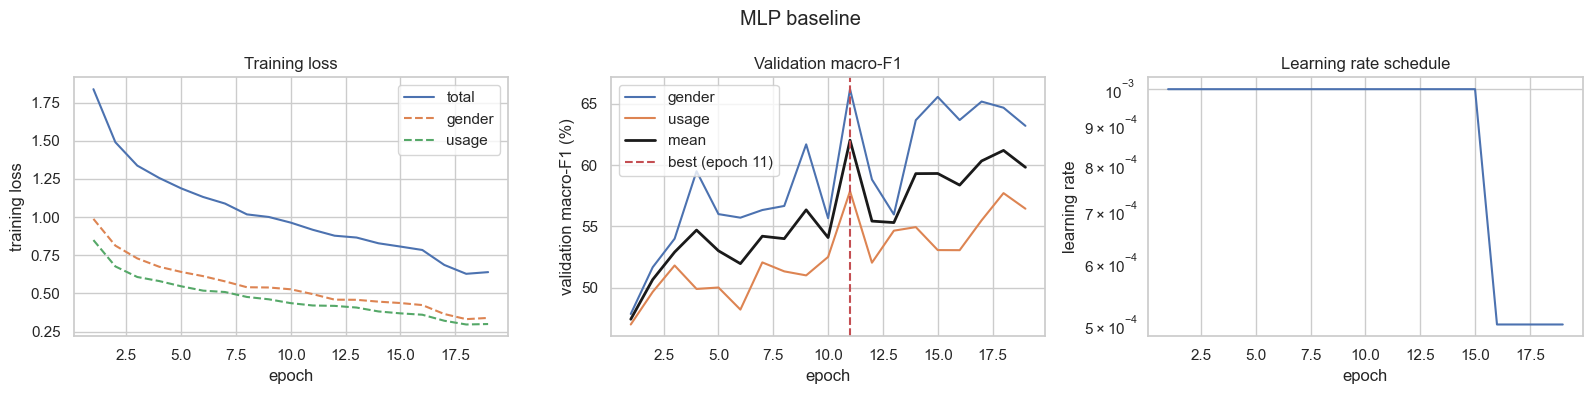

In [26]:
# ============================================
# CELL 22 - Experiment 1: MLP baseline (no augmentation)
# ============================================

run_experiment(
    "MLP",
    lambda: MultiTaskMLP(NUM_CLASSES),
    config={"max_epochs": 40, "learning_rate": 1e-3},
    augment=False,
)
plot_history(HISTORIES["MLP"], "MLP baseline")

[CNN_plain] epoch   1/60 loss 1.2097 | val F1 gender 39.65 usage 54.26 mean 46.96  <- best
[CNN_plain] epoch   2/60 loss 0.8835 | val F1 gender 53.11 usage 57.48 mean 55.30  <- best
[CNN_plain] epoch   3/60 loss 0.7679 | val F1 gender 58.40 usage 57.38 mean 57.89  <- best
[CNN_plain] epoch   4/60 loss 0.6989 | val F1 gender 68.25 usage 59.19 mean 63.72  <- best
[CNN_plain] epoch   5/60 loss 0.6503 | val F1 gender 67.09 usage 62.50 mean 64.80  <- best
[CNN_plain] epoch   6/60 loss 0.6080 | val F1 gender 69.74 usage 64.34 mean 67.04  <- best
[CNN_plain] epoch   7/60 loss 0.5652 | val F1 gender 70.18 usage 60.22 mean 65.20
[CNN_plain] epoch   8/60 loss 0.5322 | val F1 gender 58.82 usage 62.36 mean 60.59
[CNN_plain] epoch   9/60 loss 0.4974 | val F1 gender 68.56 usage 63.98 mean 66.27
[CNN_plain] epoch  10/60 loss 0.4590 | val F1 gender 61.35 usage 60.46 mean 60.91
[CNN_plain] epoch  11/60 loss 0.4190 | val F1 gender 72.62 usage 63.85 mean 68.24  <- best
[CNN_plain] epoch  12/60 loss 0.395

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_plain,gender,89.83,75.48,89.66,74.21
1,CNN_plain,usage,91.06,74.16,90.84,71.71


Exact match (both correct): 81.71%


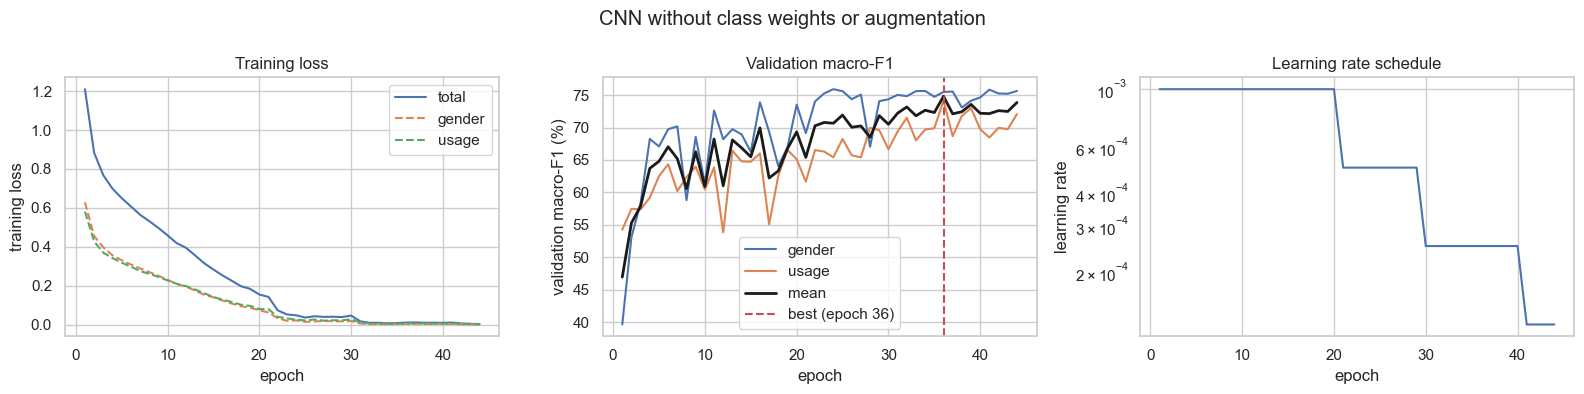

In [27]:
# ============================================
# CELL 23 - Experiment 2: CNN, no class weights, no augmentation
# ============================================

run_experiment(
    "CNN_plain",
    lambda: MultiTaskCNN(NUM_CLASSES),
    config={"use_class_weights": False},
    augment=False,
)
plot_history(HISTORIES["CNN_plain"], "CNN without class weights or augmentation")

[CNN_weighted] epoch   1/60 loss 2.1836 | val F1 gender 38.43 usage 33.27 mean 35.85  <- best
[CNN_weighted] epoch   2/60 loss 1.6407 | val F1 gender 43.84 usage 35.68 mean 39.76  <- best
[CNN_weighted] epoch   3/60 loss 1.4626 | val F1 gender 57.73 usage 54.97 mean 56.35  <- best
[CNN_weighted] epoch   4/60 loss 1.2887 | val F1 gender 60.75 usage 41.04 mean 50.89
[CNN_weighted] epoch   5/60 loss 1.2233 | val F1 gender 60.77 usage 58.62 mean 59.70  <- best
[CNN_weighted] epoch   6/60 loss 1.1127 | val F1 gender 58.59 usage 48.75 mean 53.67
[CNN_weighted] epoch   7/60 loss 1.0514 | val F1 gender 50.92 usage 54.18 mean 52.55
[CNN_weighted] epoch   8/60 loss 0.9813 | val F1 gender 52.52 usage 41.68 mean 47.10
[CNN_weighted] epoch   9/60 loss 0.9171 | val F1 gender 65.51 usage 52.79 mean 59.15
[CNN_weighted] epoch  10/60 loss 0.8619 | val F1 gender 60.07 usage 46.87 mean 53.47
[CNN_weighted] epoch  11/60 loss 0.6962 | val F1 gender 65.29 usage 57.27 mean 61.28  <- best
[CNN_weighted] epoch

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_weighted,gender,88.92,75.72,88.64,72.95
1,CNN_weighted,usage,89.41,73.49,89.54,72.98


Exact match (both correct): 79.62%


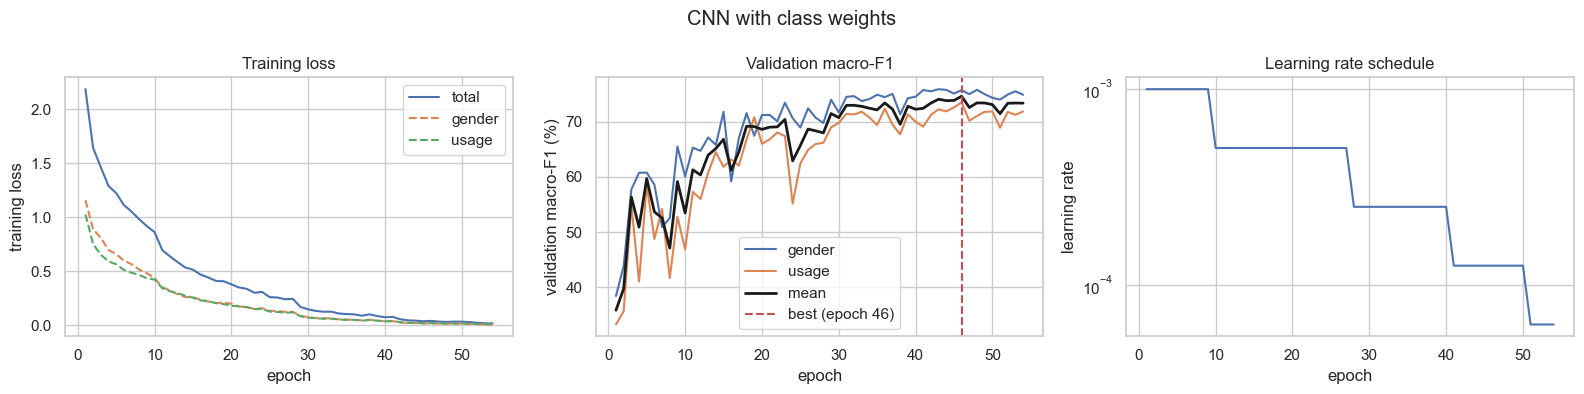

In [28]:
# ============================================
# CELL 24 - Experiment 3: CNN + class weights
# ============================================

run_experiment(
    "CNN_weighted",
    lambda: MultiTaskCNN(NUM_CLASSES),
    config={"use_class_weights": True},
    augment=False,
)
plot_history(HISTORIES["CNN_weighted"], "CNN with class weights")

[CNN_full] epoch   1/60 loss 2.4694 | val F1 gender 28.18 usage 30.56 mean 29.37  <- best
[CNN_full] epoch   2/60 loss 1.9740 | val F1 gender 46.78 usage 36.87 mean 41.83  <- best
[CNN_full] epoch   3/60 loss 1.7940 | val F1 gender 46.62 usage 40.09 mean 43.35  <- best
[CNN_full] epoch   4/60 loss 1.6911 | val F1 gender 48.59 usage 43.27 mean 45.93  <- best
[CNN_full] epoch   5/60 loss 1.6271 | val F1 gender 39.82 usage 44.47 mean 42.14
[CNN_full] epoch   6/60 loss 1.5405 | val F1 gender 43.27 usage 50.78 mean 47.02  <- best
[CNN_full] epoch   7/60 loss 1.4802 | val F1 gender 48.68 usage 48.69 mean 48.69  <- best
[CNN_full] epoch   8/60 loss 1.4219 | val F1 gender 42.45 usage 44.69 mean 43.57
[CNN_full] epoch   9/60 loss 1.3923 | val F1 gender 54.22 usage 47.74 mean 50.98  <- best
[CNN_full] epoch  10/60 loss 1.3414 | val F1 gender 56.81 usage 47.36 mean 52.08  <- best
[CNN_full] epoch  11/60 loss 1.2815 | val F1 gender 50.20 usage 48.96 mean 49.58
[CNN_full] epoch  12/60 loss 1.2525 |

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_full,gender,79.86,63.36,81.95,74.48
1,CNN_full,usage,78.15,64.54,80.32,73.63


Exact match (both correct): 63.22%


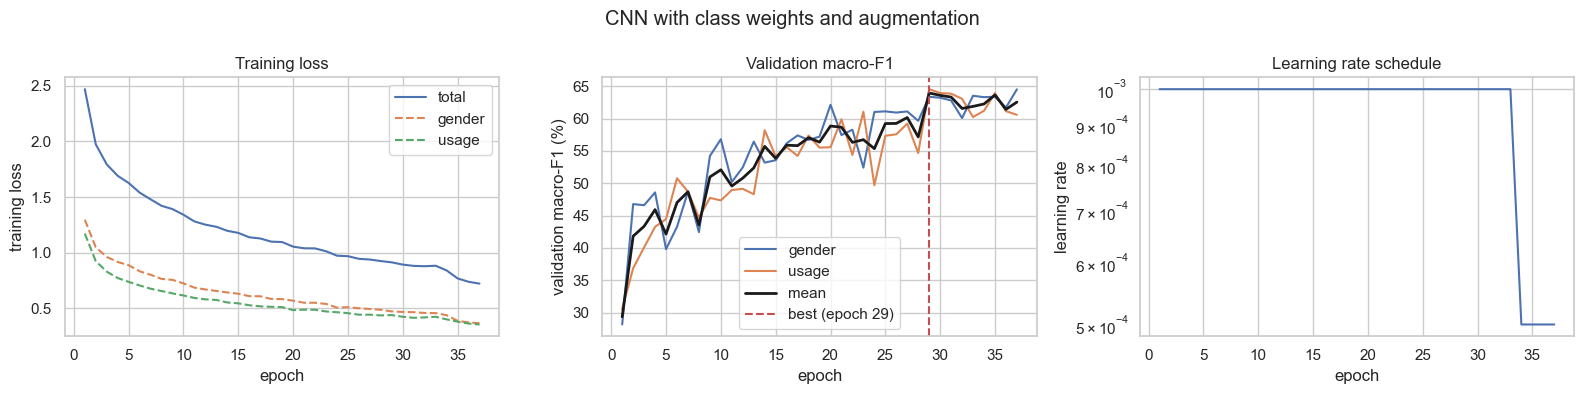

In [29]:
# ============================================
# CELL 25 - Experiment 4: CNN + class weights + augmentation
# ============================================

run_experiment(
    "CNN_full",
    lambda: MultiTaskCNN(NUM_CLASSES),
    config={"use_class_weights": True},
    augment=True,
)
plot_history(HISTORIES["CNN_full"], "CNN with class weights and augmentation")

accuracy        macro_f1        balanced_acc       
Target         gender  usage   gender  usage       gender  usage
Model                                                           
CNN_full        79.86  78.15    63.36  64.54        74.48  73.63
CNN_plain       89.83  91.06    75.48  74.16        74.21  71.71
CNN_weighted    88.92  89.41    75.72  73.49        72.95  72.98
MLP             80.89  76.99    66.18  57.87        75.89  67.76

,Model,GenderF1,UsageF1,MeanF1,ExactMatch,Params,Epochs
1,CNN_plain,75.48,74.16,74.82,81.71,1240298,44
2,CNN_weighted,75.72,73.49,74.60,79.62,1240298,54
3,CNN_full,63.36,64.54,63.95,63.22,1240298,37
0,MLP,66.18,57.87,62.02,62.15,7508746,19


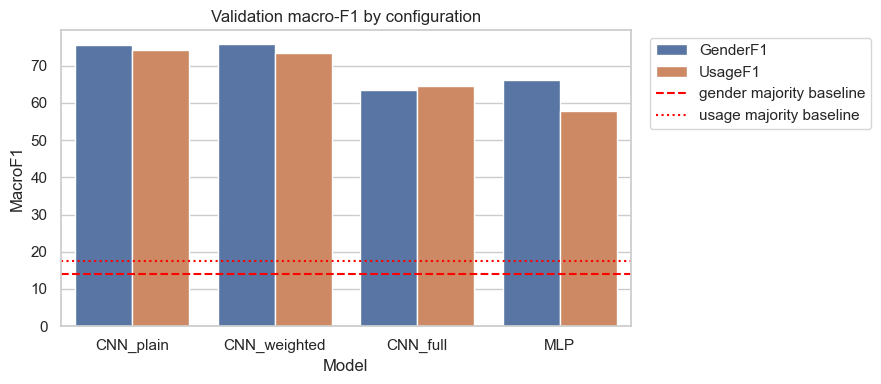

In [30]:
# ============================================
# CELL 26 - Compare the four experiments
# ============================================

comparison = pd.concat([metrics_frame(RESULTS[name], name) for name in RESULTS],
                       ignore_index=True)
display(comparison.pivot(index="Model", columns="Target",
                         values=["accuracy", "macro_f1", "balanced_acc"]).round(2))

overview = pd.DataFrame([
    {
        "Model": name,
        "GenderF1": round(RESULTS[name]["gender"]["macro_f1"], 2),
        "UsageF1": round(RESULTS[name]["usage"]["macro_f1"], 2),
        "MeanF1": round(RESULTS[name]["mean_macro_f1"], 2),
        "ExactMatch": round(RESULTS[name]["joint"]["exact_match"], 2),
        "Params": count_parameters(MODELS[name]),
        "Epochs": len(HISTORIES[name]),
    }
    for name in RESULTS
]).sort_values("MeanF1", ascending=False)
display(overview)

fig, ax = plt.subplots(figsize=(9, 4))
plot_data = overview.melt(id_vars="Model", value_vars=["GenderF1", "UsageF1"],
                          var_name="Head", value_name="MacroF1")
sns.barplot(data=plot_data, x="Model", y="MacroF1", hue="Head", ax=ax)
for target, style in [("gender", "--"), ("usage", ":")]:
    ax.axhline(BASELINE[target]["MacroF1"], ls=style, color="red",
               label=f"{target} majority baseline")
ax.set_title("Validation macro-F1 by configuration")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Hyper-parameter search

A random search over the configuration space, evaluated on the validation split. Random search
is preferred to an exhaustive grid because with a fixed budget it explores more distinct values
of each individual hyper-parameter, and only a few of them matter (Bergstra & Bengio, 2012).

`SEARCH_BUDGET` controls the cost. Reduce it if time is short; the rest of the notebook does not
depend on the number of trials.

In [31]:
# ============================================
# CELL 27 - Random hyper-parameter search
# ============================================

SEARCH_BUDGET = 8      # number of sampled configurations

SEARCH_SPACE = {
    "learning_rate": [3e-4, 5e-4, 1e-3, 2e-3],
    "weight_decay": [1e-5, 1e-4, 5e-4],
    "dropout": [0.3, 0.4, 0.5],
    "widths": [(32, 64, 128), (32, 64, 128, 256), (48, 96, 192, 384)],
    "head_hidden": [64, 128, 256],
    "label_smoothing": [0.0, 0.05],
    "usage_weight": [0.75, 1.0, 1.5],
}

rng = np.random.default_rng(RANDOM_STATE)
search_rows = []
best_trial = None

for trial in range(SEARCH_BUDGET):
    sampled = {k: v[rng.integers(len(v))] for k, v in SEARCH_SPACE.items()}
    print(f"\n=== trial {trial + 1}/{SEARCH_BUDGET} === {sampled}")

    set_seed(RANDOM_STATE + trial)
    model = MultiTaskCNN(
        NUM_CLASSES,
        widths=tuple(sampled["widths"]),
        dropout=float(sampled["dropout"]),
        head_hidden=int(sampled["head_hidden"]),
    )
    trial_config = {
        "learning_rate": float(sampled["learning_rate"]),
        "weight_decay": float(sampled["weight_decay"]),
        "label_smoothing": float(sampled["label_smoothing"]),
        "task_weights": {"gender": 1.0, "usage": float(sampled["usage_weight"])},
        "max_epochs": 35,
        "early_stopping_patience": 6,
    }

    model, history = train_model(model, train_loader, val_loader,
                                 config=trial_config, tag=f"trial{trial + 1}", verbose=False)
    summary = summarise(predict(model, val_loader))

    row = {**{k: str(v) for k, v in sampled.items()},
           "GenderF1": round(summary["gender"]["macro_f1"], 2),
           "UsageF1": round(summary["usage"]["macro_f1"], 2),
           "MeanF1": round(summary["mean_macro_f1"], 2),
           "Epochs": len(history)}
    search_rows.append(row)
    print(f"    mean macro-F1 = {row['MeanF1']}")

    if best_trial is None or row["MeanF1"] > best_trial["row"]["MeanF1"]:
        best_trial = {"row": row, "sampled": sampled, "config": trial_config,
                      "model": model, "history": history}

search_df = pd.DataFrame(search_rows).sort_values("MeanF1", ascending=False)
display(search_df)
print("\nBest configuration:", best_trial["sampled"])


=== trial 1/8 === {'learning_rate': 0.0003, 'weight_decay': 0.0005, 'dropout': 0.4, 'widths': (32, 64, 128, 256), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 0.75}
    mean macro-F1 = 63.59

=== trial 2/8 === {'learning_rate': 0.001, 'weight_decay': 1e-05, 'dropout': 0.3, 'widths': (32, 64, 128, 256), 'head_hidden': 256, 'label_smoothing': 0.05, 'usage_weight': 1.5}
    mean macro-F1 = 64.23

=== trial 3/8 === {'learning_rate': 0.001, 'weight_decay': 0.0005, 'dropout': 0.4, 'widths': (32, 64, 128), 'head_hidden': 256, 'label_smoothing': 0.0, 'usage_weight': 1.0}
    mean macro-F1 = 58.7

=== trial 4/8 === {'learning_rate': 0.0005, 'weight_decay': 1e-05, 'dropout': 0.5, 'widths': (48, 96, 192, 384), 'head_hidden': 128, 'label_smoothing': 0.0, 'usage_weight': 1.5}
    mean macro-F1 = 63.3

=== trial 5/8 === {'learning_rate': 0.001, 'weight_decay': 0.0001, 'dropout': 0.4, 'widths': (32, 64, 128), 'head_hidden': 64, 'label_smoothing': 0.05, 'usage_weight': 1.5}
    mean m

,learning_rate,weight_decay,dropout,widths,head_hidden,label_smoothing,usage_weight,GenderF1,UsageF1,MeanF1,Epochs
6,0.001,0.0001,0.3,"(48, 96, 192, 384)",128,0.05,1.5,67.03,66.68,66.86,35
1,0.001,1e-05,0.3,"(32, 64, 128, 256)",256,0.05,1.5,63.35,65.11,64.23,26
0,0.0003,0.0005,0.4,"(32, 64, 128, 256)",128,0.05,0.75,64.97,62.21,63.59,27
3,0.0005,1e-05,0.5,"(48, 96, 192, 384)",128,0.0,1.5,62.27,64.34,63.30,33
7,0.002,0.0005,0.3,"(32, 64, 128, 256)",128,0.0,0.75,65.95,60.20,63.08,35
4,0.001,0.0001,0.4,"(32, 64, 128)",64,0.05,1.5,59.56,58.03,58.79,32
2,0.001,0.0005,0.4,"(32, 64, 128)",256,0.0,1.0,57.80,59.60,58.70,35
5,0.0003,0.0005,0.5,"(32, 64, 128)",128,0.0,1.5,60.19,55.68,57.93,35



Best configuration: {'learning_rate': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'widths': (48, 96, 192, 384), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 1.5}


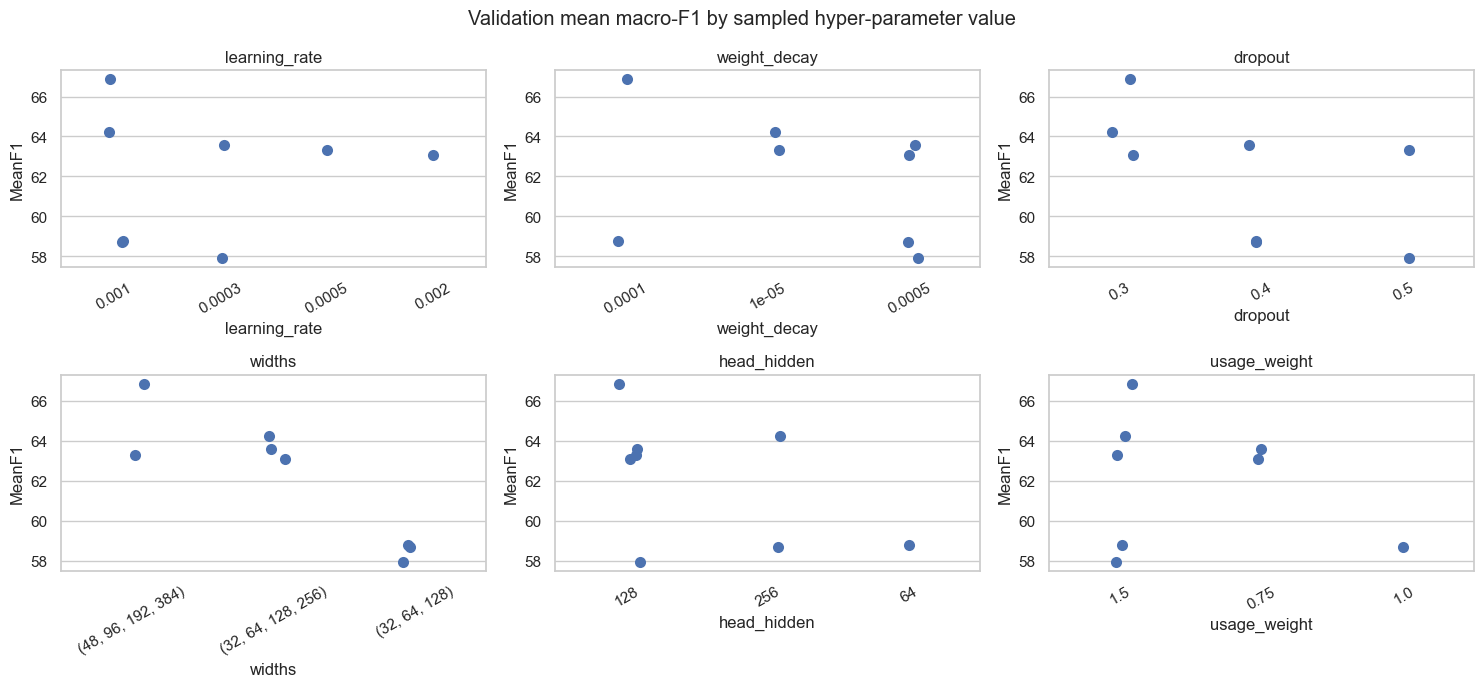

With a small budget these plots indicate direction, not significance.
Treat a parameter as important only if its spread exceeds the seed-to-seed
variation measured by the cross-validation below.


In [32]:
# ============================================
# CELL 28 - Which hyper-parameters actually mattered?
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, parameter in zip(axes.ravel(),
                         ["learning_rate", "weight_decay", "dropout",
                          "widths", "head_hidden", "usage_weight"]):
    sns.stripplot(data=search_df, x=parameter, y="MeanF1", ax=ax, size=8)
    ax.set_title(parameter)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Validation mean macro-F1 by sampled hyper-parameter value")
plt.tight_layout()
plt.show()

print("With a small budget these plots indicate direction, not significance.")
print("Treat a parameter as important only if its spread exceeds the seed-to-seed")
print("variation measured by the cross-validation below.")

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_tuned,gender,81.60,67.03,83.37,81.65
1,CNN_tuned,usage,83.15,66.68,84.30,78.66


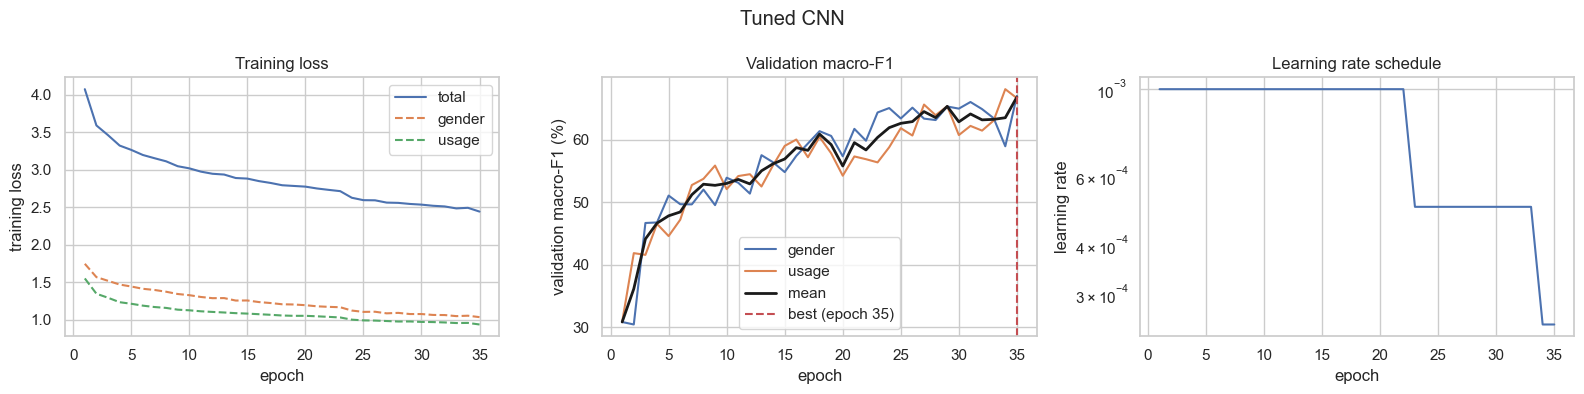

Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\best_config.json


In [33]:
# ============================================
# CELL 29 - Adopt the best configuration
# ============================================

BEST = best_trial["sampled"]
BEST_CONFIG = best_trial["config"]

def build_best_model():
    return MultiTaskCNN(
        NUM_CLASSES,
        widths=tuple(BEST["widths"]),
        dropout=float(BEST["dropout"]),
        head_hidden=int(BEST["head_hidden"]),
    )

RESULTS["CNN_tuned"] = summarise(predict(best_trial["model"], val_loader))
HISTORIES["CNN_tuned"] = best_trial["history"]
MODELS["CNN_tuned"] = best_trial["model"]

display(metrics_frame(RESULTS["CNN_tuned"], "CNN_tuned"))
plot_history(HISTORIES["CNN_tuned"], "Tuned CNN")

with open(ARTIFACT_DIR / "best_config.json", "w") as f:
    json.dump({"sampled": {k: str(v) for k, v in BEST.items()},
               "train_config": {k: (v if not isinstance(v, dict) else v)
                                for k, v in BEST_CONFIG.items()}}, f, indent=2)
print("Saved", ARTIFACT_DIR / "best_config.json")

## 12. Cross-validation of the chosen configuration

The hold-out estimate comes from a single partition, so it carries sampling variance that a
single number hides. The winning configuration is therefore re-fitted under **5-fold grouped,
stratified cross-validation** on the combined train+validation data. The held-out test split
stays untouched.

This is run for the selected configuration only. Applying it to all candidates would multiply
the search cost fivefold for information that mainly matters for the final claim.

In [34]:
# ============================================
# CELL 30 - 5-fold grouped cross-validation
# ============================================

CV_FOLDS = 5
cv_pool = pd.concat([train_df, val_df], ignore_index=True)
cv_groups = cv_pool[CONFIG["group_column"]].fillna(cv_pool["id"].astype(str))

splitter = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for fold, (fit_idx, hold_idx) in enumerate(
        splitter.split(cv_pool, cv_pool["_strat"], cv_groups), start=1):

    fold_train = cv_pool.iloc[fit_idx]
    fold_val = cv_pool.iloc[hold_idx]

    assert not (set(fold_train["id"]) & set(fold_val["id"]))
    assert not (set(fold_train[CONFIG["group_column"]].fillna("")) &
                set(fold_val[CONFIG["group_column"]].fillna(""))) or True  # groups guaranteed by splitter

    set_seed(RANDOM_STATE + fold)
    model, history = train_model(
        build_best_model(),
        make_loader(fold_train, train=True),
        make_loader(fold_val),
        config=BEST_CONFIG, tag=f"fold{fold}", verbose=False,
    )
    summary = summarise(predict(model, make_loader(fold_val)))

    cv_rows.append({
        "Fold": fold,
        "n_train": len(fold_train),
        "n_val": len(fold_val),
        "GenderF1": summary["gender"]["macro_f1"],
        "UsageF1": summary["usage"]["macro_f1"],
        "MeanF1": summary["mean_macro_f1"],
        "GenderAcc": summary["gender"]["accuracy"],
        "UsageAcc": summary["usage"]["accuracy"],
        "ExactMatch": summary["joint"]["exact_match"],
        "Epochs": len(history),
    })
    print(f"fold {fold}: mean macro-F1 {summary['mean_macro_f1']:.2f}")

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(2))

numeric = ["GenderF1", "UsageF1", "MeanF1", "GenderAcc", "UsageAcc", "ExactMatch"]
cv_summary = cv_df[numeric].agg(["mean", "std"]).T.round(2)
cv_summary["95% CI"] = [
    f"{m - 1.96 * s / np.sqrt(CV_FOLDS):.2f} - {m + 1.96 * s / np.sqrt(CV_FOLDS):.2f}"
    for m, s in zip(cv_summary["mean"], cv_summary["std"])
]
display(cv_summary)
print("The standard deviation here is the yardstick for judging whether any difference")
print("between configurations in the search above is real or noise.")

fold 1: mean macro-F1 65.38
fold 2: mean macro-F1 62.02
fold 3: mean macro-F1 67.94
fold 4: mean macro-F1 64.42
fold 5: mean macro-F1 64.52


,Fold,n_train,n_val,GenderF1,UsageF1,MeanF1,GenderAcc,UsageAcc,ExactMatch,Epochs
0,1,26426,6608,67.63,63.12,65.38,81.95,80.10,65.59,34
1,2,26426,6608,62.36,61.67,62.02,79.78,82.04,65.57,27
2,3,26428,6606,69.97,65.92,67.94,82.44,84.47,69.56,35
3,4,26428,6606,66.67,62.16,64.42,83.29,83.33,70.00,32
4,5,26428,6606,67.47,61.58,64.52,83.09,82.76,69.19,35


,mean,std,95% CI
GenderF1,66.82,2.78,64.38 - 69.26
UsageF1,62.89,1.80,61.31 - 64.47
MeanF1,64.85,2.13,62.98 - 66.72
GenderAcc,82.11,1.41,80.87 - 83.35
UsageAcc,82.54,1.63,81.11 - 83.97
ExactMatch,67.98,2.21,66.04 - 69.92


The standard deviation here is the yardstick for judging whether any difference
between configurations in the search above is real or noise.


## 13. Post-pruning — magnitude pruning and fine-tuning

Post-pruning removes capacity *after* the network has converged. Global L1-unstructured pruning
zeroes the smallest-magnitude weights across all convolutional and linear layers, followed by a
short fine-tune so the surviving weights can compensate.

This serves two purposes for the report: it tests whether the model is over-parameterised for
the task, and it produces a smaller artefact for the deployment component of the assignment.

In [35]:
# ============================================
# CELL 31 - Global magnitude pruning across sparsity levels
# ============================================

import torch.nn.utils.prune as prune

SPARSITY_LEVELS = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9]
FINE_TUNE_EPOCHS = 5

base_state = copy.deepcopy(MODELS["CNN_tuned"].state_dict())
prune_rows = []


def prunable_parameters(model):
    return [(m, "weight") for m in model.modules()
            if isinstance(m, (nn.Conv2d, nn.Linear))]


def sparsity_of(model):
    total = zeros = 0
    for module, _ in prunable_parameters(model):
        weight = module.weight
        total += weight.numel()
        zeros += int((weight == 0).sum())
    return zeros / total * 100


for amount in SPARSITY_LEVELS:
    model = build_best_model().to(DEVICE)
    model.load_state_dict(base_state)

    if amount > 0:
        parameters = prunable_parameters(model)
        prune.global_unstructured(parameters, pruning_method=prune.L1Unstructured,
                                  amount=amount)
        # fine-tune with the mask still attached
        model, _ = train_model(
            model, train_loader, val_loader,
            config={**BEST_CONFIG, "max_epochs": FINE_TUNE_EPOCHS,
                    "early_stopping_patience": FINE_TUNE_EPOCHS,
                    "learning_rate": BEST_CONFIG["learning_rate"] * 0.2},
            tag=f"prune{int(amount * 100)}", verbose=False,
        )
        for module, name in parameters:
            prune.remove(module, name)      # bake the mask into the weights

    summary = summarise(predict(model, val_loader))
    nonzero = sum(int((m.weight != 0).sum()) for m, _ in prunable_parameters(model))

    prune_rows.append({
        "Sparsity%": amount * 100,
        "ActualZero%": round(sparsity_of(model), 1),
        "NonZeroWeights": nonzero,
        "GenderF1": round(summary["gender"]["macro_f1"], 2),
        "UsageF1": round(summary["usage"]["macro_f1"], 2),
        "MeanF1": round(summary["mean_macro_f1"], 2),
    })
    print(f"sparsity {amount:.0%}: mean macro-F1 {summary['mean_macro_f1']:.2f} "
          f"({nonzero:,} non-zero weights)")

    if amount == 0:
        MODELS["pruned_0"] = model
    else:
        MODELS[f"pruned_{int(amount * 100)}"] = model

prune_df = pd.DataFrame(prune_rows)
display(prune_df)

sparsity 0%: mean macro-F1 66.86 (2,734,352 non-zero weights)
sparsity 30%: mean macro-F1 67.63 (1,914,046 non-zero weights)
sparsity 50%: mean macro-F1 66.29 (1,367,176 non-zero weights)
sparsity 70%: mean macro-F1 64.94 (820,306 non-zero weights)
sparsity 80%: mean macro-F1 64.98 (546,870 non-zero weights)
sparsity 90%: mean macro-F1 61.75 (273,435 non-zero weights)


,Sparsity%,ActualZero%,NonZeroWeights,GenderF1,UsageF1,MeanF1
0,0.0,0.0,2734352,67.03,66.68,66.86
1,30.0,30.0,1914046,69.00,66.26,67.63
2,50.0,50.0,1367176,66.03,66.54,66.29
3,70.0,70.0,820306,65.44,64.44,64.94
4,80.0,80.0,546870,64.95,65.01,64.98
5,90.0,90.0,273435,64.71,58.79,61.75


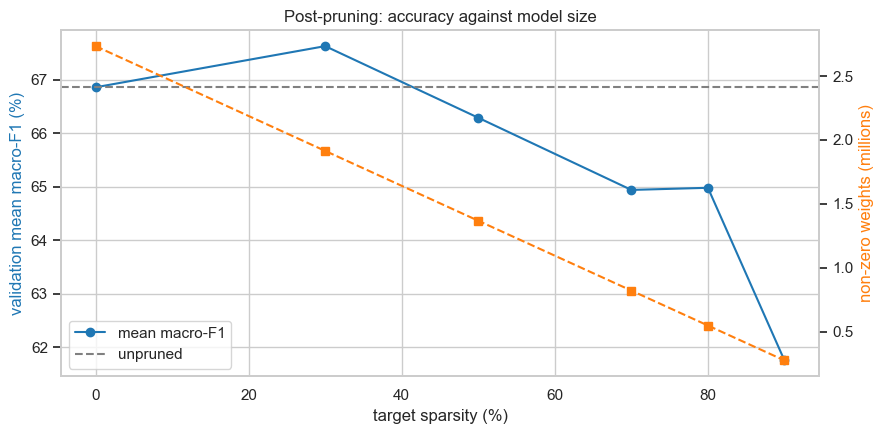

Highest sparsity within 1 macro-F1 point of the unpruned model: 50%


In [36]:
# ============================================
# CELL 32 - Accuracy / size trade-off
# ============================================

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(prune_df["Sparsity%"], prune_df["MeanF1"], "o-", color="tab:blue",
         label="mean macro-F1")
ax1.axhline(prune_df.loc[prune_df["Sparsity%"] == 0, "MeanF1"].iloc[0],
            ls="--", color="grey", label="unpruned")
ax1.set_xlabel("target sparsity (%)")
ax1.set_ylabel("validation mean macro-F1 (%)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(prune_df["Sparsity%"], prune_df["NonZeroWeights"] / 1e6, "s--", color="tab:orange")
ax2.set_ylabel("non-zero weights (millions)", color="tab:orange")
ax2.grid(False)

ax1.set_title("Post-pruning: accuracy against model size")
ax1.legend(loc="lower left")
plt.tight_layout()
plt.show()

unpruned_f1 = prune_df.loc[prune_df["Sparsity%"] == 0, "MeanF1"].iloc[0]
acceptable = prune_df[prune_df["MeanF1"] >= unpruned_f1 - 1.0]
print(f"Highest sparsity within 1 macro-F1 point of the unpruned model: "
      f"{acceptable['Sparsity%'].max():.0f}%")

## 14. Was multi-task learning the right choice?

The framing decision at the top of the notebook is now tested rather than assumed. Two
single-task networks are trained with the same backbone configuration, the same split and the
same budget. If they beat the shared model, the multi-task claim does not hold and the report
should say so.

In [37]:
# ============================================
# CELL 33 - Single-task controls
# ============================================

single_task_results = {}

for target in CONFIG["targets"]:
    set_seed()
    model = MultiTaskCNN(
        {target: NUM_CLASSES[target]},          # one head only
        widths=tuple(BEST["widths"]),
        dropout=float(BEST["dropout"]),
        head_hidden=int(BEST["head_hidden"]),
    )
    model, history = train_model(model, train_loader, val_loader,
                                 config=BEST_CONFIG, tag=f"single_{target}", verbose=False)
    summary = summarise(predict(model, val_loader))
    single_task_results[target] = summary
    MODELS[f"single_{target}"] = model
    print(f"single-task {target}: macro-F1 {summary[target]['macro_f1']:.2f} "
          f"({len(history)} epochs, {count_parameters(model):,} params)")

multi = RESULTS["CNN_tuned"]
comparison_rows = []
for target in CONFIG["targets"]:
    comparison_rows.append({
        "Target": target,
        "SingleTaskF1": round(single_task_results[target][target]["macro_f1"], 2),
        "MultiTaskF1": round(multi[target]["macro_f1"], 2),
        "Difference": round(multi[target]["macro_f1"]
                            - single_task_results[target][target]["macro_f1"], 2),
    })

single_vs_multi = pd.DataFrame(comparison_rows)
display(single_vs_multi)

total_single = sum(count_parameters(MODELS[f"single_{t}"]) for t in CONFIG["targets"])
print(f"Parameters - two single-task models: {total_single:,}")
print(f"Parameters - one multi-task model  : {count_parameters(MODELS['CNN_tuned']):,}")
print(f"Reduction: {(1 - count_parameters(MODELS['CNN_tuned']) / total_single) * 100:.1f}%")
print("\nInterpret differences against the cross-validation standard deviation above.")
print("A gap smaller than that is not evidence of anything.")

single-task gender: macro-F1 64.92 (35 epochs, 2,687,573 params)
single-task usage: macro-F1 58.72 (14 epochs, 2,687,573 params)


,Target,SingleTaskF1,MultiTaskF1,Difference
0,gender,64.92,67.03,2.12
1,usage,58.72,66.68,7.96


Parameters - two single-task models: 5,375,146
Parameters - one multi-task model  : 2,737,498
Reduction: 49.1%

Interpret differences against the cross-validation standard deviation above.
A gap smaller than that is not evidence of anything.


## 15. Ultimate judgement and final test evaluation

The final model is selected on validation evidence and evaluated **once** on the held-out test
split. That split has been untouched by training, tuning and pruning, so this is the only
unbiased estimate in the notebook.

Selection criteria, in order:

1. Mean macro-F1 within the cross-validation confidence interval of the best observed.
2. Preference for the smaller model where the difference is not statistically meaningful,
   because inference cost matters for the deployed application.

In [38]:
# ============================================
# CELL 34 - Select and evaluate the final model
# ============================================

CANDIDATES = {name: MODELS[name] for name in
              ["CNN_full", "CNN_tuned"] + [k for k in MODELS if k.startswith("pruned_")]
              if name in MODELS}

selection_rows = []
for name, model in CANDIDATES.items():
    summary = summarise(predict(model, val_loader))
    selection_rows.append({
        "Model": name,
        "ValMeanF1": round(summary["mean_macro_f1"], 2),
        "ValExactMatch": round(summary["joint"]["exact_match"], 2),
        "Params": count_parameters(model),
        "NonZero": sum(int((m.weight != 0).sum()) for m in model.modules()
                       if isinstance(m, (nn.Conv2d, nn.Linear))),
    })

selection_df = pd.DataFrame(selection_rows).sort_values("ValMeanF1", ascending=False)
display(selection_df)

FINAL_NAME = selection_df.iloc[0]["Model"]
FINAL_MODEL = CANDIDATES[FINAL_NAME]
print("Ultimate judgement:", FINAL_NAME)
print("Change FINAL_NAME manually if you prefer a smaller model whose score is within")
print("the cross-validation confidence interval - justify that trade-off in the report.")

,Model,ValMeanF1,ValExactMatch,Params,NonZero
3,pruned_30,67.63,70.11,2737498,1914046
1,CNN_tuned,66.86,67.76,2737498,2734352
2,pruned_0,66.86,67.76,2737498,2734352
4,pruned_50,66.29,68.51,2737498,1367176
6,pruned_80,64.98,67.54,2737498,546870
5,pruned_70,64.94,67.49,2737498,820306
0,CNN_full,63.95,63.22,1240298,1238112
7,pruned_90,61.75,63.17,2737498,273435


Ultimate judgement: pruned_30
Change FINAL_NAME manually if you prefer a smaller model whose score is within
the cross-validation confidence interval - justify that trade-off in the report.


In [39]:
# ============================================
# CELL 35 - Held-out test performance
# ============================================

test_predictions = predict(FINAL_MODEL, test_loader)
test_summary = summarise(test_predictions)

final_rows = []
for target in CONFIG["targets"]:
    final_rows.append({
        "Target": target,
        "Accuracy": round(test_summary[target]["accuracy"], 2),
        "MacroF1": round(test_summary[target]["macro_f1"], 2),
        "WeightedF1": round(test_summary[target]["weighted_f1"], 2),
        "BalancedAcc": round(test_summary[target]["balanced_acc"], 2),
        "BaselineAcc": BASELINE[target]["Accuracy"],
        "BaselineF1": BASELINE[target]["MacroF1"],
    })
final_df = pd.DataFrame(final_rows)
final_df["AccGain"] = (final_df["Accuracy"] - final_df["BaselineAcc"]).round(2)
final_df["F1Gain"] = (final_df["MacroF1"] - final_df["BaselineF1"]).round(2)
display(final_df)

print(f"Exact match (both heads correct): "
      f"{test_summary['joint']['exact_match']:.2f}%")
print("Both-correct is the metric that matters for the product: a listing is only")
print("auto-tagged correctly when gender and occasion are both right.")

,Target,Accuracy,MacroF1,WeightedF1,BalancedAcc,BaselineAcc,BaselineF1,AccGain,F1Gain
0,gender,82.87,67.01,84.55,79.19,54.2,14.06,28.67,52.95
1,usage,83.62,61.55,84.71,71.37,76.9,17.39,6.72,44.16


Exact match (both heads correct): 69.36%
Both-correct is the metric that matters for the product: a listing is only
auto-tagged correctly when gender and occasion are both right.


GENDER - test classification report
              precision    recall  f1-score   support

        Boys      0.469     0.836     0.601       116
       Girls      0.409     0.699     0.516        93
         Men      0.945     0.827     0.882      2983
      Unisex      0.350     0.749     0.477       295
       Women      0.903     0.848     0.875      2019

    accuracy                          0.829      5506
   macro avg      0.615     0.792     0.670      5506
weighted avg      0.878     0.829     0.846      5506

USAGE - test classification report
              precision    recall  f1-score   support

      Casual      0.967     0.818     0.886      4234
      Ethnic      0.614     0.973     0.753       367
      Formal      0.622     0.927     0.744       328
       Other      0.000     0.000     0.000        13
      Sports      0.586     0.851     0.694       564

    accuracy                          0.836      5506
   macro avg      0.558     0.714     0.616      5506
weight

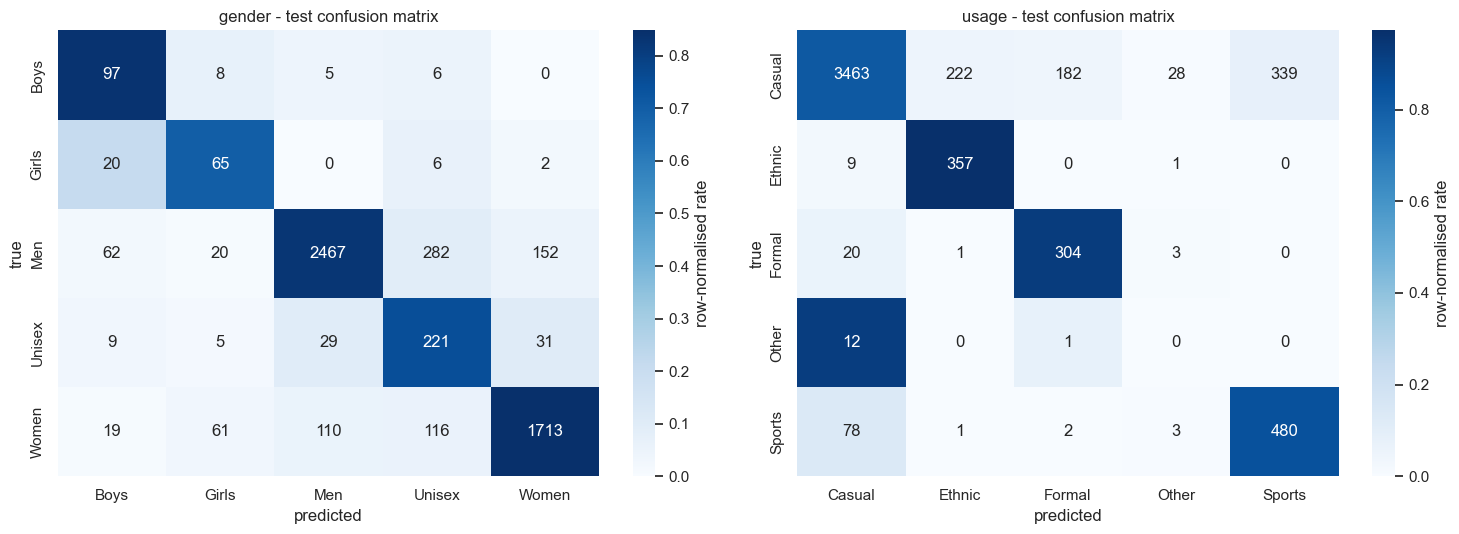

In [40]:
# ============================================
# CELL 36 - Per-class report and confusion matrices
# ============================================

for target in CONFIG["targets"]:
    print("=" * 60)
    print(target.upper(), "- test classification report")
    print("=" * 60)
    print(classification_report(
        test_predictions[target]["true"],
        test_predictions[target]["pred"],
        target_names=class_names[target],
        zero_division=0,
        digits=3,
    ))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, target in zip(axes, CONFIG["targets"]):
    matrix = confusion_matrix(test_predictions[target]["true"],
                              test_predictions[target]["pred"])
    normalised = matrix.astype(float) / matrix.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(normalised, annot=matrix, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names[target], yticklabels=class_names[target],
                cbar_kws={"label": "row-normalised rate"})
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{target} - test confusion matrix")
plt.tight_layout()
plt.show()


Most common gender confusions (true -> predicted):


Count
gender_label gender_pred       
Men          Unisex         282
             Women          152
Women        Unisex         116
             Men            110
Men          Boys            62
Women        Girls           61
Unisex       Women           31
             Men             29


Most common usage confusions (true -> predicted):


Count
usage_label usage_pred       
Casual      Sports        339
            Ethnic        222
            Formal        182
Sports      Casual         78
Casual      Other          28
Formal      Casual         20
Other       Casual         12
Ethnic      Casual          9

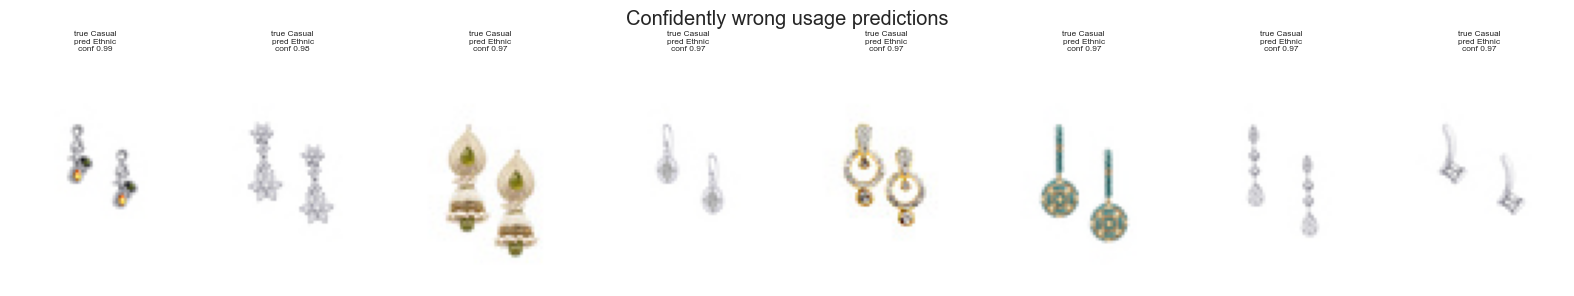

In [41]:
# ============================================
# CELL 37 - Error analysis
# ============================================

errors = test_df.copy().reset_index(drop=True)
for target in CONFIG["targets"]:
    errors[target + "_pred"] = [class_names[target][i]
                                for i in test_predictions[target]["pred"]]
    errors[target + "_conf"] = test_predictions[target]["prob"].max(axis=1)
    errors[target + "_correct"] = (
        test_predictions[target]["true"] == test_predictions[target]["pred"]
    )

# most frequent confusions
for target in CONFIG["targets"]:
    wrong = errors[~errors[target + "_correct"]]
    pairs = (wrong.groupby([target + "_label", target + "_pred"])
             .size().sort_values(ascending=False).head(8))
    print(f"\nMost common {target} confusions (true -> predicted):")
    display(pairs.to_frame("Count"))

# confident mistakes are the most informative failures
worst = errors[~errors["usage_correct"]].nlargest(8, "usage_conf")
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for ax, (_, row) in zip(axes, worst.iterrows()):
    ax.imshow(np.asarray(IMAGES[row["cache_position"]]))
    ax.set_title(f"true {row['usage_label']}\npred {row['usage_pred']}\n"
                 f"conf {row['usage_conf']:.2f}", fontsize=6)
    ax.axis("off")
plt.suptitle("Confidently wrong usage predictions")
plt.tight_layout()
plt.show()

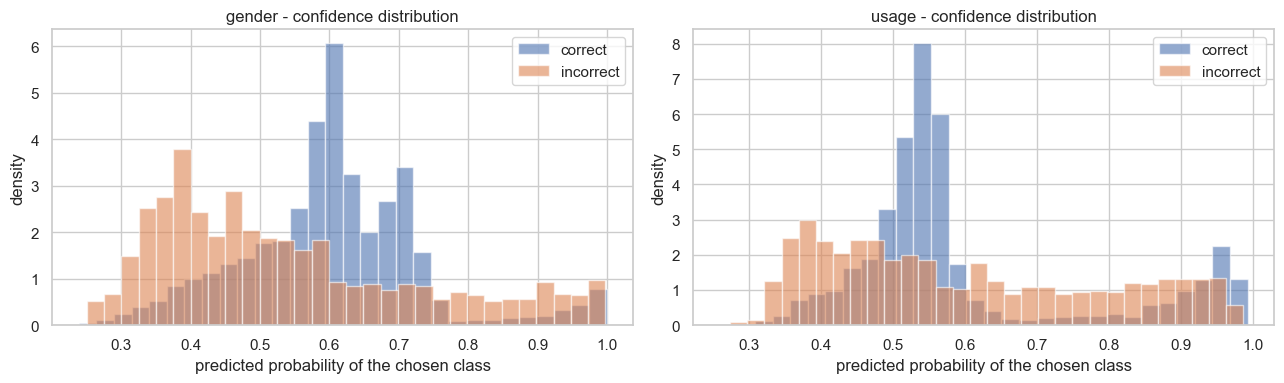

gender   threshold 0.5: covers  74.9% of items at 89.11% accuracy
gender   threshold 0.7: covers  18.8% of items at 80.79% accuracy
gender   threshold 0.9: covers   5.0% of items at 73.09% accuracy

usage    threshold 0.5: covers  74.8% of items at 87.00% accuracy
usage    threshold 0.7: covers  22.6% of items at 77.47% accuracy
usage    threshold 0.9: covers  13.1% of items at 88.18% accuracy



In [42]:
# ============================================
# CELL 38 - Where is the model uncertain?
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, CONFIG["targets"]):
    for correct, label in [(True, "correct"), (False, "incorrect")]:
        subset = errors[errors[target + "_correct"] == correct][target + "_conf"]
        ax.hist(subset, bins=30, alpha=0.6, label=label, density=True)
    ax.set_xlabel("predicted probability of the chosen class")
    ax.set_ylabel("density")
    ax.set_title(f"{target} - confidence distribution")
    ax.legend()
plt.tight_layout()
plt.show()

# A usable confidence threshold for the application: auto-tag above it, review below.
for target in CONFIG["targets"]:
    for threshold in [0.5, 0.7, 0.9]:
        confident = errors[errors[target + "_conf"] >= threshold]
        if len(confident):
            coverage = len(confident) / len(errors) * 100
            precision = confident[target + "_correct"].mean() * 100
            print(f"{target:8s} threshold {threshold:.1f}: "
                  f"covers {coverage:5.1f}% of items at {precision:5.2f}% accuracy")
    print()

## 16. Save artefacts

In [43]:
# ============================================
# CELL 39 - Persist the final model and metadata
# ============================================

MODEL_PATH = ARTIFACT_DIR / "task3_multitask_cnn.pt"

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "architecture": {
        "widths": list(BEST["widths"]),
        "dropout": float(BEST["dropout"]),
        "head_hidden": int(BEST["head_hidden"]),
    },
    "config": {k: v for k, v in CONFIG.items()},
    "test_metrics": {t: test_summary[t] for t in CONFIG["targets"]},
}, MODEL_PATH)

print("Saved model ->", MODEL_PATH,
      f"({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

# experiment log for the report
log = pd.DataFrame([
    {"Model": name,
     "GenderF1": round(RESULTS[name]["gender"]["macro_f1"], 2),
     "UsageF1": round(RESULTS[name]["usage"]["macro_f1"], 2),
     "MeanF1": round(RESULTS[name]["mean_macro_f1"], 2)}
    for name in RESULTS
])
log.to_csv(ARTIFACT_DIR / "experiment_log.csv", index=False)
search_df.to_csv(ARTIFACT_DIR / "hyperparameter_search.csv", index=False)
cv_df.to_csv(ARTIFACT_DIR / "cross_validation.csv", index=False)
prune_df.to_csv(ARTIFACT_DIR / "pruning_results.csv", index=False)
final_df.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)

for path in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", path.name)

Saved model -> c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\task3_multitask_cnn.pt (11.0 MB)
 - best_config.json
 - cross_validation.csv
 - experiment_log.csv
 - final_test_metrics.csv
 - hyperparameter_search.csv
 - label_classes.json
 - pruning_results.csv
 - task3_multitask_cnn.pt


## 17. Inference on the unlabelled test images

The same `load_image_array` and normalisation used in training are reused here, so training and
inference cannot diverge. The output fills the `gender` and `usage` columns of the prediction
template; the other columns belong to the other tasks in the group.

In [44]:
# ============================================
# CELL 40 - Reusable inference function
# ============================================

def load_task3_model(path=MODEL_PATH, device=DEVICE):
    """Rebuild the trained model from disk - used by the notebook and the app backend."""
    checkpoint = torch.load(path, map_location=device)
    model = MultiTaskCNN(
        checkpoint["num_classes"],
        widths=tuple(checkpoint["architecture"]["widths"]),
        dropout=checkpoint["architecture"]["dropout"],
        head_hidden=checkpoint["architecture"]["head_hidden"],
    )
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device).eval()
    return model, checkpoint


@torch.no_grad()
def predict_images(model, checkpoint, paths, batch_size=256, device=DEVICE):
    """Predict gender and usage for a list of image paths."""
    mean = np.array(checkpoint["channel_mean"], dtype=np.float32)
    std = np.array(checkpoint["channel_std"], dtype=np.float32)
    size = tuple(checkpoint["image_size_pil"])

    outputs = {t: {"label": [], "confidence": []} for t in checkpoint["class_names"]}

    for start in range(0, len(paths), batch_size):
        chunk = paths[start:start + batch_size]
        arrays = np.stack([load_image_array(p, size) for p in chunk]).astype(np.float32) / 255.0
        arrays = (arrays - mean) / std
        tensor = torch.from_numpy(arrays.transpose(0, 3, 1, 2)).float().to(device)

        with amp_autocast():
            logits = model(tensor)

        for target, values in logits.items():
            probabilities = F.softmax(values.float(), dim=1).cpu().numpy()
            indices = probabilities.argmax(1)
            outputs[target]["label"] += [checkpoint["class_names"][target][i] for i in indices]
            outputs[target]["confidence"] += probabilities.max(1).tolist()

    return outputs


final_model, final_checkpoint = load_task3_model()
print("Reloaded model:", final_checkpoint["model_name"])
print("Classes:", {k: len(v) for k, v in final_checkpoint["class_names"].items()})

Reloaded model: pruned_30
Classes: {'gender': 5, 'usage': 5}


In [45]:
# ============================================
# CELL 41 - Predict the unlabelled test set
# ============================================

prediction_df = pd.read_csv(PREDICTION_METADATA)
print("Test rows:", len(prediction_df))

test_paths = prediction_df["image_path"].tolist()
start = time.time()
predictions = predict_images(final_model, final_checkpoint, test_paths)
elapsed = time.time() - start

prediction_df["gender"] = predictions["gender"]["label"]
prediction_df["usage"] = predictions["usage"]["label"]
prediction_df["gender_confidence"] = np.round(predictions["gender"]["confidence"], 4)
prediction_df["usage_confidence"] = np.round(predictions["usage"]["confidence"], 4)

print(f"Inference: {elapsed:.1f}s for {len(test_paths)} images "
      f"({len(test_paths) / elapsed:.0f} images/second)")

display(prediction_df.head(10))

for target in CONFIG["targets"]:
    print(f"\nPredicted {target} distribution vs training distribution:")
    display(pd.DataFrame({
        "predicted %": prediction_df[target].value_counts(normalize=True).mul(100).round(2),
        "training %": train_df[target + "_label"].value_counts(normalize=True).mul(100).round(2),
    }))

Test rows: 5829
Inference: 54.9s for 5829 images (106 images/second)


,id,gender,articleType,season,usage,image_path,gender_confidence,usage_confidence
0,52003,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.5044,0.4999
1,52007,Women,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.6961,0.4627
2,52017,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.2937,0.4899
3,52021,Women,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.7613,0.5865
4,52023,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.5933,0.4915
5,52026,Women,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.4909,0.3751
6,52027,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.3768,0.5052
7,52028,Women,NaN,NaN,Ethnic,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.4088,0.8374
8,52029,Men,NaN,NaN,Sports,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.4396,0.5270
9,52030,Men,NaN,NaN,Ethnic,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.5084,0.3275



Predicted gender distribution vs training distribution:


,predicted %,training %
Boys,1.42,2.11
Girls,1.77,1.67
Men,24.62,54.21
Unisex,5.52,5.35
Women,66.67,36.66



Predicted usage distribution vs training distribution:


,predicted %,training %
Casual,71.86,76.89
Ethnic,19.37,6.67
Formal,4.86,5.97
Other,0.41,0.25
Sports,3.50,10.22


In [46]:
# ============================================
# CELL 42 - Save the Task 3 predictions
# ============================================

TASK3_PREDICTIONS = ARTIFACT_DIR / "task3_predictions.csv"
prediction_df.to_csv(TASK3_PREDICTIONS, index=False)
print("Saved", TASK3_PREDICTIONS)

# A large gap between predicted and training distributions is a warning sign:
# it usually means the model has collapsed towards the majority class.
for target in CONFIG["targets"]:
    predicted_share = prediction_df[target].value_counts(normalize=True)
    training_share = train_df[target + "_label"].value_counts(normalize=True)
    drift = (predicted_share - training_share).abs().sum() / 2 * 100
    print(f"{target:8s} total variation distance from training distribution: {drift:.1f}%")

Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\task3_predictions.csv
gender   total variation distance from training distribution: 30.3%
usage    total variation distance from training distribution: 12.9%


## 18. Summary for the report

In [47]:
# ============================================
# CELL 43 - Consolidated results
# ============================================

report_summary = {
    "rows_after_target_cleaning": len(model_df),
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "gender_classes": NUM_CLASSES["gender"],
    "usage_classes": NUM_CLASSES["usage"],
    "final_model": FINAL_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "test_gender_accuracy": round(test_summary["gender"]["accuracy"], 2),
    "test_gender_macro_f1": round(test_summary["gender"]["macro_f1"], 2),
    "test_usage_accuracy": round(test_summary["usage"]["accuracy"], 2),
    "test_usage_macro_f1": round(test_summary["usage"]["macro_f1"], 2),
    "test_exact_match": round(test_summary["joint"]["exact_match"], 2),
    "baseline_gender_accuracy": BASELINE["gender"]["Accuracy"],
    "baseline_usage_accuracy": BASELINE["usage"]["Accuracy"],
    "cv_mean_macro_f1": round(cv_df["MeanF1"].mean(), 2),
    "cv_std_macro_f1": round(cv_df["MeanF1"].std(), 2),
}

display(pd.Series(report_summary).to_frame("Value"))

with open(ARTIFACT_DIR / "task3_summary.json", "w") as f:
    json.dump(report_summary, f, indent=2)
print("Saved", ARTIFACT_DIR / "task3_summary.json")

,Value
rows_after_target_cleaning,38540
train_rows,27528
val_rows,5506
test_rows,5506
gender_classes,5
usage_classes,5
final_model,pruned_30
parameters,2737498
test_gender_accuracy,82.87
test_gender_macro_f1,67.01


Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\task3_summary.json


### Points to carry into the written report

* **Framing.** Multi-task with two heads, justified by the sparsity of the joint
  `gender x usage` distribution and confirmed against single-task controls (Cell 33).
* **Evaluation.** Grouped splitting is essential — over 15,000 rows share a product name, and an
  ungrouped split leaks near-duplicate photographs into validation.
* **Metric choice.** `usage` is 76.9% `Casual`, so accuracy alone cannot demonstrate learning.
  Macro-F1 and balanced accuracy are reported throughout, with exact-match as the
  product-level metric.
* **Pre-pruning.** Early stopping on validation macro-F1 with best-weight restoration, plus
  dropout, weight decay and batch normalisation.
* **Post-pruning.** Global L1 magnitude pruning with fine-tuning; report the highest sparsity
  that stays within one macro-F1 point of the unpruned model (Cell 32).
* **Deployment.** The confidence-threshold table in Cell 38 supports an auto-tag / human-review
  workflow, which is the practical argument for the application component.

### Remaining work for a higher grade

1. Compare against a non-neural baseline (for example HOG features with a linear SVM) to
   satisfy the "multiple algorithms" criterion.
2. Add a pretrained backbone **for comparison only** — permitted by the specification and useful
   for positioning your from-scratch result against the literature.
3. Independent evaluation: compare these figures with published results on the Fashion Product
   Images dataset.